# Workflow Baseline Full Run – Both Routes
Plots built from `output/workflow_baseline_full_run_both_routes/{bm25,dense,hybrid}`.

https://github.com/fulaibaowang/BioASQ/issues/4

## 1. Imports and Setup

In [9]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

## 2. Load Data

In [10]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent

print("Base dir:", base_dir)

workflow_dir = base_dir / "output" / "workflow_baseline_full_run_both_routes"

bm25_metrics = pd.read_csv(workflow_dir / "bm25" / "metrics.csv")
dense_metrics = pd.read_csv(workflow_dir / "dense" / "metrics.csv")
hybrid_metrics = pd.read_csv(workflow_dir / "hybrid" / "metrics.csv")

# Normalise split column name
bm25_metrics = bm25_metrics.rename(columns={"batch": "split"})
dense_metrics = dense_metrics.rename(columns={"batch": "split"})

bm25_metrics["method"] = "BM25"
dense_metrics["method"] = "Dense"
hybrid_metrics["method"] = "BM25 Dense Fusion"

output_dir = workflow_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

# Final figures used in the working note. Everything not listed here is still
# generated for debugging in `output_dir`, but only the files below get copied
# (or written directly) to `workingnotes/figures/` for inclusion in the report.
wn_output_dir = base_dir / "workingnotes" / "figures"
wn_output_dir.mkdir(parents=True, exist_ok=True)

# Matplotlib rc for figures that land in workingnotes/figures (see §18, §8c, §11c).
WORKINGNOTE_FIG_RC: dict[str, object] = {
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "legend.fontsize": 13,
}


def _wn_mapk_xticks(ks: list[int]) -> list[int]:
    """Sparse MAP@K x tick labels (curves still use every k in ks)."""
    order = (1, 5, 10, 20, 30, 50, 75, 100)
    return [k for k in order if k in ks]


def _wn_medcpt_mapk_xticks(ks: list[int]) -> list[int]:
    order = (10, 40, 70, 100)
    return [k for k in order if k in ks]


def _wn_hybrid_recall_xticks(ks: list[int]) -> list[int]:
    order = (10, 200, 2000)
    return [k for k in order if k in ks]

print("Loaded BM25:", bm25_metrics.shape)
print("Loaded Dense:", dense_metrics.shape)
print("Loaded Hybrid:", hybrid_metrics.shape)

Base dir: /Users/yun/develop/BioASQ
Loaded BM25: (5, 17)
Loaded Dense: (5, 17)
Loaded Hybrid: (5, 28)


## 3. Stage 1 Recall Curves – Per Split (3×2 panels)

Shared K values: [10, 50, 100, 200, 300, 400, 500, 1000, 2000, 5000]
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/01_stage1_recall_per_split.png


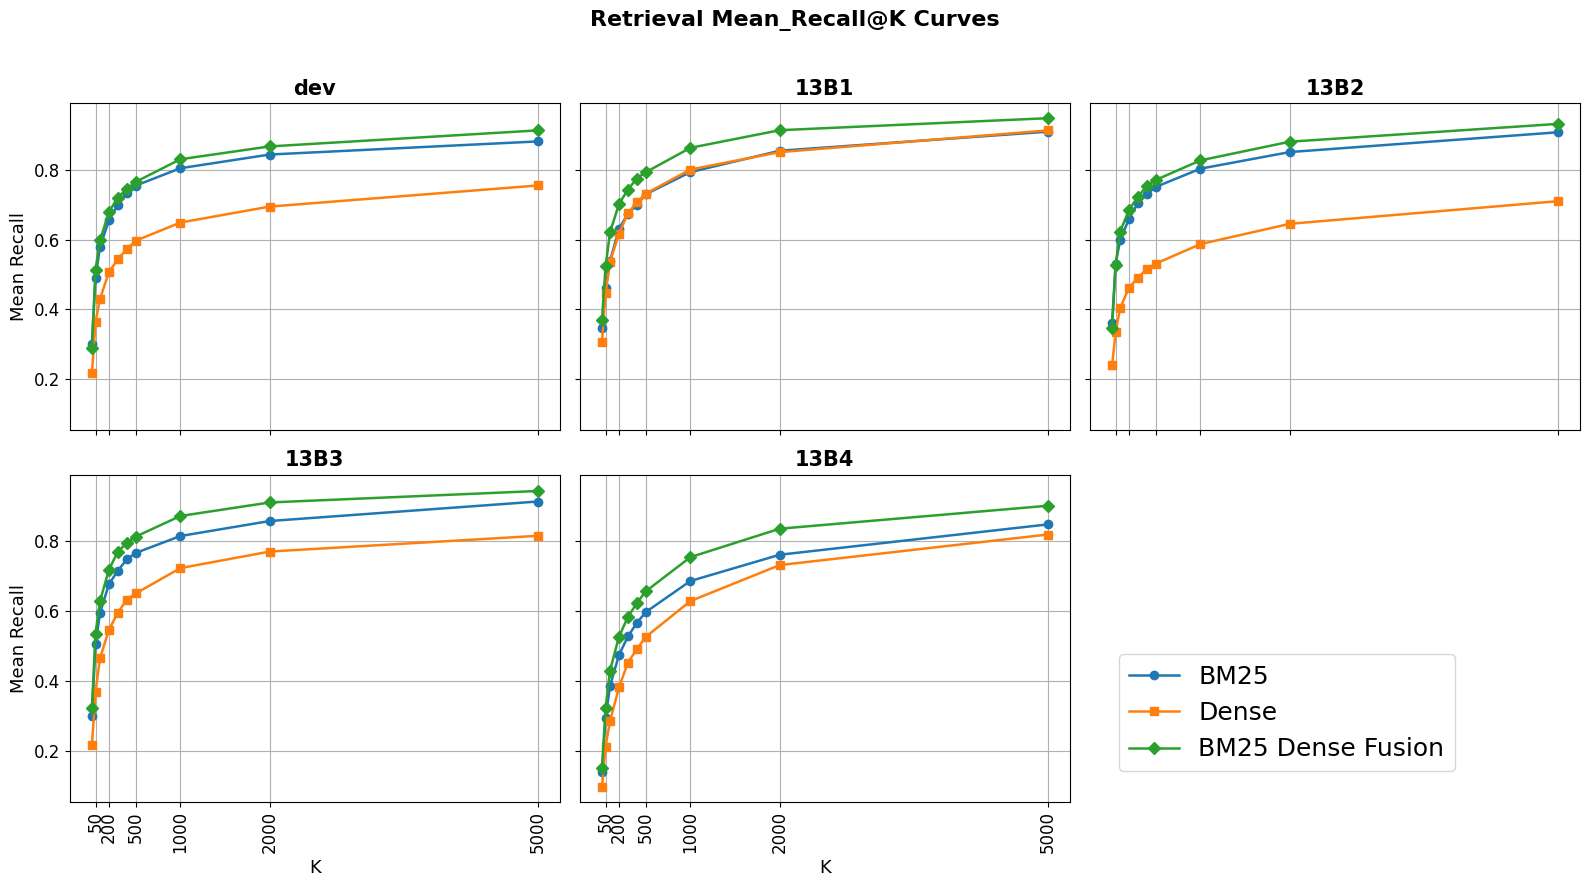

In [11]:
splits = [
    "training14b_10pct_sample",
    "13B1_golden",
    "13B2_golden",
    "13B3_golden",
    "13B4_golden",
]
split_labels = {
    "training14b_10pct_sample": "dev",
    "13B1_golden": "13B1",
    "13B2_golden": "13B2",
    "13B3_golden": "13B3",
    "13B4_golden": "13B4",
}

recall_cols_bm25 = sorted(
    [c for c in bm25_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols_hybrid = sorted(
    [c for c in hybrid_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols = sorted(
    set(recall_cols_bm25) & set(recall_cols_hybrid),
    key=lambda c: int(c.split("@")[1]),
)
k_values = [int(c.split("@")[1]) for c in recall_cols]

print("Shared K values:", k_values)

# Only show a subset of K ticks to avoid clutter.
tick_candidates = [50, 200, 500, 1000, 2000, 5000]
tick_values = [k for k in tick_candidates if k in k_values]

methods_cfg = {
    "BM25": {"df": bm25_metrics, "color": "#1f77b4", "marker": "o"},
    "Dense": {"df": dense_metrics, "color": "#ff7f0e", "marker": "s"},
    "BM25 Dense Fusion": {"df": hybrid_metrics, "color": "#2ca02c", "marker": "D"},
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes_flat = list(axes.flat)

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_cfg.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
global_ymax = min(1, global_ymax + y_pad)

for idx, split in enumerate(splits):
    ax = axes_flat[idx]
    for method_name, cfg in methods_cfg.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        ax.plot(
            k_values,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    ax.set_title(split_labels.get(split, split), fontsize=15, fontweight="bold")
    ax.set_ylim(global_ymin, global_ymax)

    # Y-axis label only for left column (two left plots)
    if idx % 3 == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    # X-axis label (and tick labels) only for bottom row (two bottom plots actually used)
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(tick_values)
        ax.set_xticklabels([str(k) for k in tick_values], rotation=90)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    # Grid: horizontal lines on all panels, vertical lines at selected K ticks
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

for j in range(len(splits), len(axes_flat)):
    axes_flat[j].remove()

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.92, 0.12), fontsize=18)

fig.suptitle("Retrieval Mean_Recall@K Curves", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = output_dir / "01_stage1_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/01b_stage1_recall_dev_vs_test_merged.png


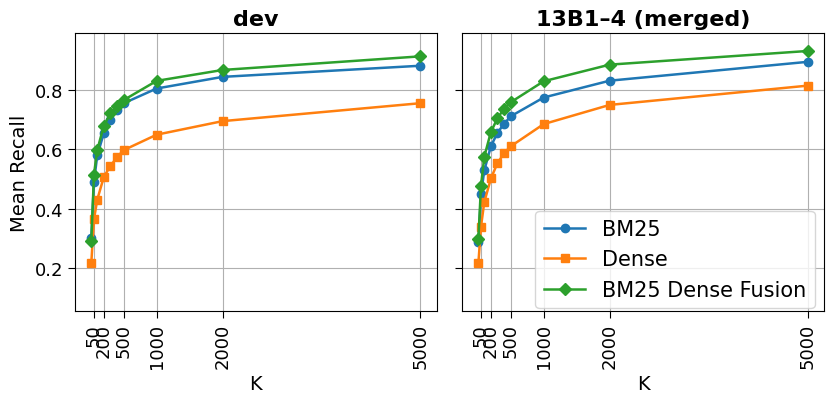

In [12]:
with plt.rc_context(WORKINGNOTE_FIG_RC):
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.2), sharex=True, sharey=True)

    for idx, (panel_label, panel_splits) in enumerate([
        ("dev", ["training14b_10pct_sample"]),
        ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
    ]):
        ax = axes[idx]
        for method_name, cfg in methods_cfg.items():
            all_vals = []
            for s in panel_splits:
                row = cfg["df"][cfg["df"]["split"] == s]
                if not row.empty:
                    all_vals.append([row.iloc[0][c] for c in recall_cols])
            if not all_vals:
                continue
            vals = np.mean(all_vals, axis=0)
            ax.plot(
                k_values,
                vals,
                marker=cfg["marker"],
                color=cfg["color"],
                label=method_name,
                markersize=6,
                linewidth=1.8,
            )
        ax.set_title(panel_label, fontsize=16, fontweight="bold")
        ax.set_ylim(global_ymin, global_ymax)
        if idx == 0:
            ax.set_ylabel("Mean Recall")
        ax.set_xlabel("K")
        ax.set_xticks(tick_values)
        ax.set_xticklabels([str(k) for k in tick_values], rotation=90)
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.98, 0.22), fontsize=15)
    plt.tight_layout()

fig_path = output_dir / "01b_stage1_recall_dev_vs_test_merged.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 4. Hybrid vs Rerank vs Post-rerank Fusion – Recall Curves (K ≤ 300)

Stage2+ K values (≤300): [10, 50, 100, 200, 300]
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/02_hybrid_rerank_fusion_recall_per_split.png


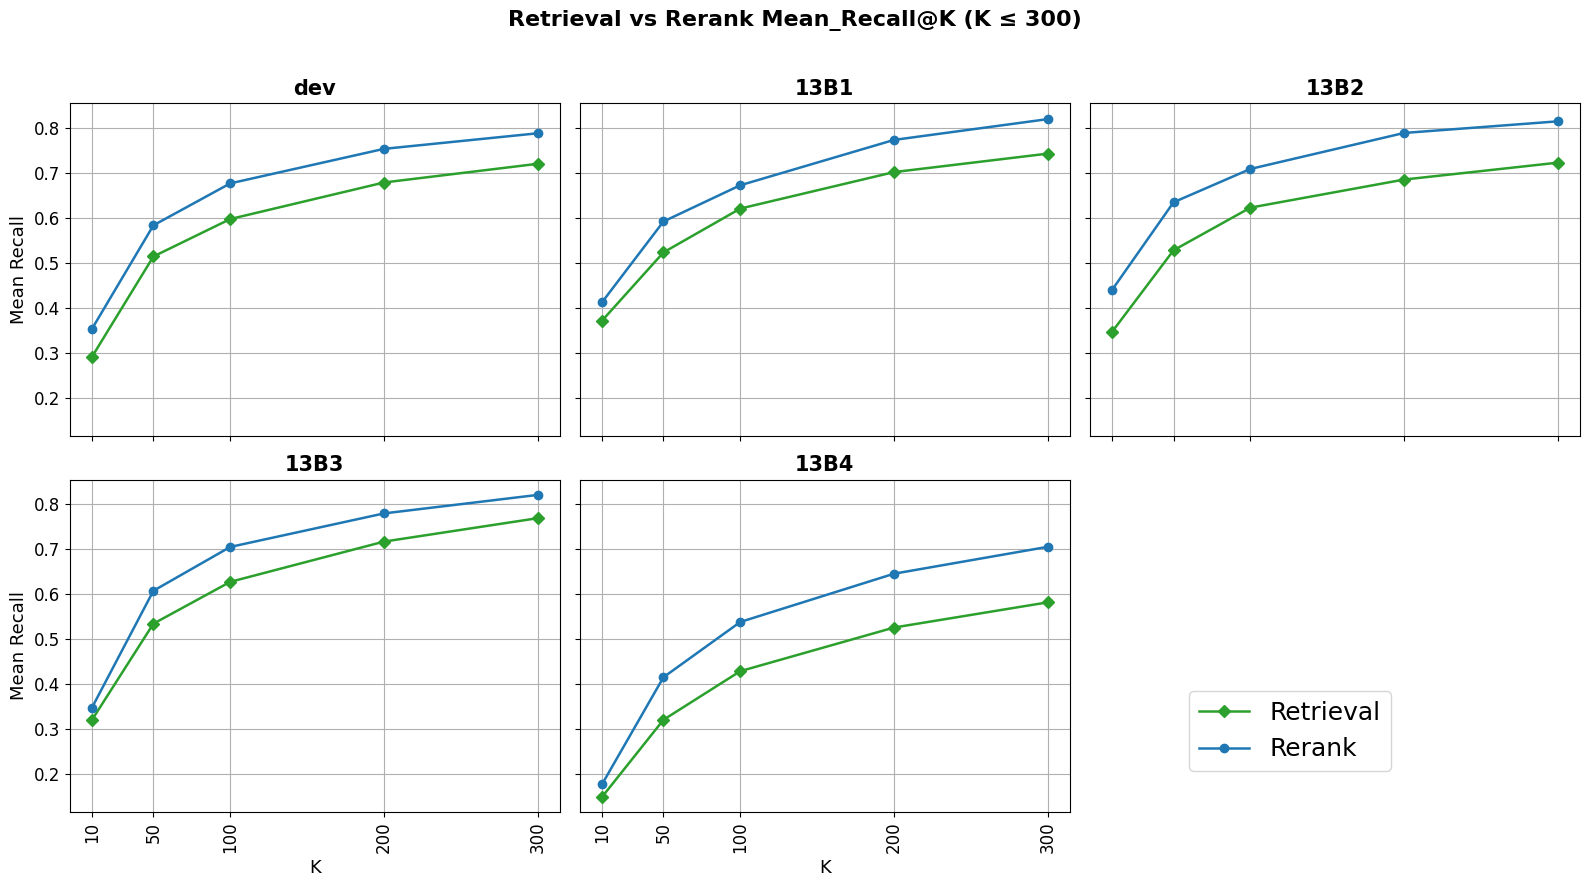

In [13]:
hybrid_stage1 = hybrid_metrics.copy()
rerank_metrics = pd.read_csv(workflow_dir / "rerank" / "metrics.csv")
rerank_fusion_metrics = pd.read_csv(workflow_dir / "rerank_hybrid_200" / "metrics.csv")

# Rerank uses 'label' for split name
rerank_metrics = rerank_metrics.rename(columns={"label": "split"})

methods_stage2 = {
    "Retrieval": {
        "df": hybrid_stage1,
        "color": "#2ca02c",
        "marker": "D",
    },
    "Rerank": {
        "df": rerank_metrics,
        "color": "#1f77b4",
        "marker": "o",
    },
}

# Shared MeanR@K columns with K in [10, 300]
recall_cols_all = []
for df in [hybrid_stage1, rerank_metrics]:
    cols = [c for c in df.columns if c.startswith("MeanR@")]
    recall_cols_all.append(set(cols))

recall_cols_common = sorted(
    set.intersection(*recall_cols_all),
    key=lambda c: int(c.split("@")[1]),
)
k_vals_recall = [int(c.split("@")[1]) for c in recall_cols_common if 10 <= int(c.split("@")[1]) <= 300]
recall_cols_common = [f"MeanR@{k}" for k in k_vals_recall]

print("Stage2+ K values (≤300):", k_vals_recall)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes_flat = list(axes.flat)

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_stage2.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
global_ymax = min(1, global_ymax + y_pad)

tick_candidates_recall = [10, 50, 100, 200, 300,]
tick_values_recall = [k for k in tick_candidates_recall if k in k_vals_recall]

for idx, split in enumerate(splits):
    ax = axes_flat[idx]
    for method_name, cfg in methods_stage2.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        ax.plot(
            k_vals_recall,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    ax.set_title(split_labels.get(split, split), fontsize=15, fontweight="bold")
    ax.set_ylim(global_ymin, global_ymax)

    if idx % 3 == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(tick_values_recall)
        ax.set_xticklabels([str(k) for k in tick_values_recall], rotation=90)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

for j in range(len(splits), len(axes_flat)):
    axes_flat[j].remove()

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.88, 0.12), fontsize=18)

fig.suptitle("Retrieval vs Rerank Mean_Recall@K (K ≤ 300)", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = output_dir / "02_hybrid_rerank_fusion_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/02b_hybrid_rerank_fusion_recall_dev_vs_test_merged.png


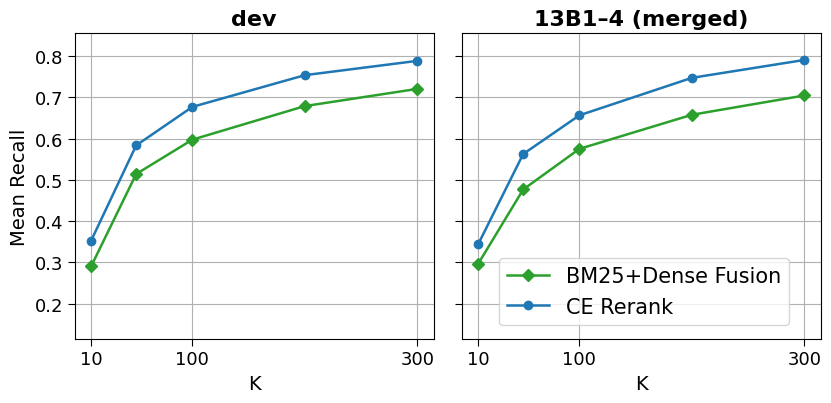

In [16]:
_xt_02b = [k for k in (10, 100, 300) if k in tick_values_recall]
_wn_method_labels_02b = {"Retrieval": "BM25+Dense Fusion", "Rerank": "CE Rerank"}
with plt.rc_context(WORKINGNOTE_FIG_RC):
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.2), sharex=True, sharey=True)

    for idx, (panel_label, panel_splits) in enumerate([
        ("dev", ["training14b_10pct_sample"]),
        ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
    ]):
        ax = axes[idx]
        for method_name, cfg in methods_stage2.items():
            all_vals = []
            for s in panel_splits:
                row = cfg["df"][cfg["df"]["split"] == s]
                if not row.empty:
                    all_vals.append([row.iloc[0][c] for c in recall_cols_common])
            if not all_vals:
                continue
            vals = np.mean(all_vals, axis=0)
            ax.plot(
                k_vals_recall,
                vals,
                marker=cfg["marker"],
                color=cfg["color"],
                label=_wn_method_labels_02b.get(method_name, method_name),
                markersize=6,
                linewidth=1.8,
            )
        ax.set_title(panel_label, fontsize=16, fontweight="bold")
        ax.set_ylim(global_ymin, global_ymax)
        if idx == 0:
            ax.set_ylabel("Mean Recall")
        ax.set_xlabel("K")
        ax.set_xticks(_xt_02b)
        ax.set_xticklabels([str(k) for k in _xt_02b])
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.95, 0.18), fontsize=15)
    plt.tight_layout()

fig_path = output_dir / "02b_hybrid_rerank_fusion_recall_dev_vs_test_merged.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 5. Hybrid vs Rerank vs Post-rerank Fusion – MAP@10 (Bar Plots)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/03_hybrid_rerank_fusion_map10_bars_per_split.png


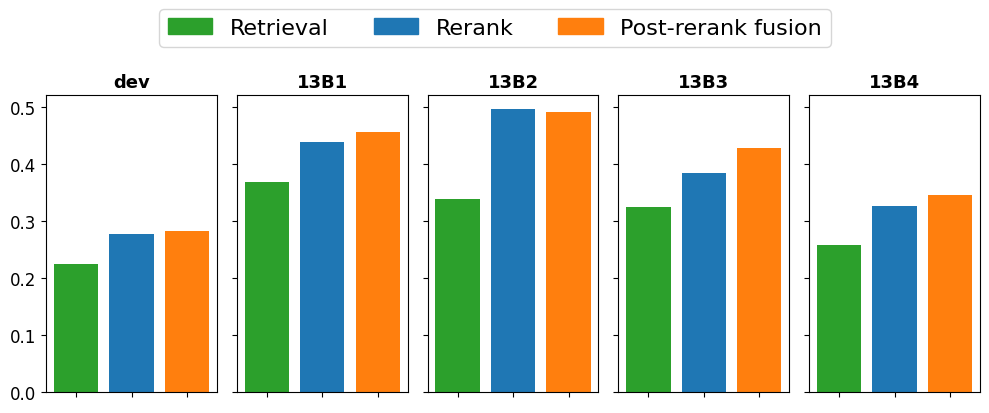

In [31]:
fig, ax = plt.subplots(1, 5, figsize=(10, 4), sharey=True)
# fig.suptitle("Retrival vs Rerank vs Post-rerank Fusion – MAP@10", fontsize=16, fontweight="bold", y=1.08)
method_colors = {
    "Retrieval": "#2ca02c",
    "Rerank": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

for idx, split in enumerate(splits):
    cur_ax = ax[idx]
    vals = []
    labels_methods = []

    # Hybrid retrieval
    row_h = hybrid_stage1[hybrid_stage1["split"] == split]
    if not row_h.empty:
        vals.append(float(row_h.iloc[0]["MAP@10"]))
        labels_methods.append("Retrieval")

    # Rerank
    row_r = rerank_metrics[rerank_metrics["split"] == split]
    if not row_r.empty:
        vals.append(float(row_r.iloc[0]["MAP@10"]))
        labels_methods.append("Rerank")

    # Post-rerank fusion
    row_f = rerank_fusion_metrics[rerank_fusion_metrics["split"] == split]
    if not row_f.empty:
        vals.append(float(row_f.iloc[0]["MAP@10"]))
        labels_methods.append("Post-rerank fusion")

    x = np.arange(len(labels_methods))
    colors = [method_colors[label] for label in labels_methods]
    cur_ax.bar(x, vals, color=colors)
    cur_ax.set_xticks(x)
    cur_ax.set_xticklabels("", rotation=30, ha="right")
    cur_ax.set_title(split_labels.get(split, split), fontsize=13, fontweight="bold")

# Legend for methods instead of y-axis label
handles = [
    plt.matplotlib.patches.Patch(color=method_colors["Retrieval"], label="Retrieval"),
    plt.matplotlib.patches.Patch(color=method_colors["Rerank"], label="Rerank"),
    plt.matplotlib.patches.Patch(color=method_colors["Post-rerank fusion"], label="Post-rerank fusion"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.9])
fig_path = output_dir / "03_hybrid_rerank_fusion_map10_bars_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/03b_hybrid_rerank_fusion_map10_bars_dev_vs_test_merged.png


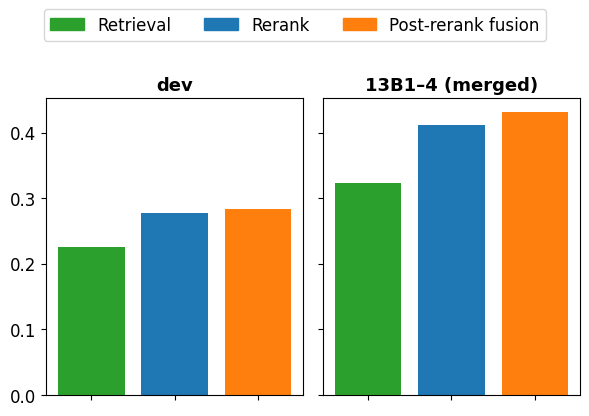

In [32]:
_method_colors_bar = {
    "Retrieval": "#2ca02c",
    "Rerank": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

fig, ax = plt.subplots(1, 2, figsize=(6, 4), sharey=True)

for idx, (panel_label, panel_splits) in enumerate([
    ("dev", ["training14b_10pct_sample"]),
    ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
]):
    cur_ax = ax[idx]
    vals = []
    labels_m = []

    map10_h = [float(hybrid_stage1[hybrid_stage1["split"] == s].iloc[0]["MAP@10"])
               for s in panel_splits if not hybrid_stage1[hybrid_stage1["split"] == s].empty]
    if map10_h:
        vals.append(np.mean(map10_h))
        labels_m.append("Retrieval")

    map10_r = [float(rerank_metrics[rerank_metrics["split"] == s].iloc[0]["MAP@10"])
               for s in panel_splits if not rerank_metrics[rerank_metrics["split"] == s].empty]
    if map10_r:
        vals.append(np.mean(map10_r))
        labels_m.append("Rerank")

    map10_f = [float(rerank_fusion_metrics[rerank_fusion_metrics["split"] == s].iloc[0]["MAP@10"])
               for s in panel_splits if not rerank_fusion_metrics[rerank_fusion_metrics["split"] == s].empty]
    if map10_f:
        vals.append(np.mean(map10_f))
        labels_m.append("Post-rerank fusion")

    x = np.arange(len(labels_m))
    colors = [_method_colors_bar[label] for label in labels_m]
    cur_ax.bar(x, vals, color=colors)
    cur_ax.set_xticks(x)
    cur_ax.set_xticklabels("", rotation=30, ha="right")
    cur_ax.set_title(panel_label, fontsize=13, fontweight="bold")

handles = [
    plt.matplotlib.patches.Patch(color=_method_colors_bar["Retrieval"], label="Retrieval"),
    plt.matplotlib.patches.Patch(color=_method_colors_bar["Rerank"], label="Rerank"),
    plt.matplotlib.patches.Patch(color=_method_colors_bar["Post-rerank fusion"], label="Post-rerank fusion"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.9])
fig_path = output_dir / "03b_hybrid_rerank_fusion_map10_bars_dev_vs_test_merged.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 6. Hybrid vs Rerank vs Post-rerank Fusion – MAP@K Curves (K = 1, 3, 5, 10, 20, 30, 40, 50)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/04_hybrid_rerank_fusion_mapk_per_split.png


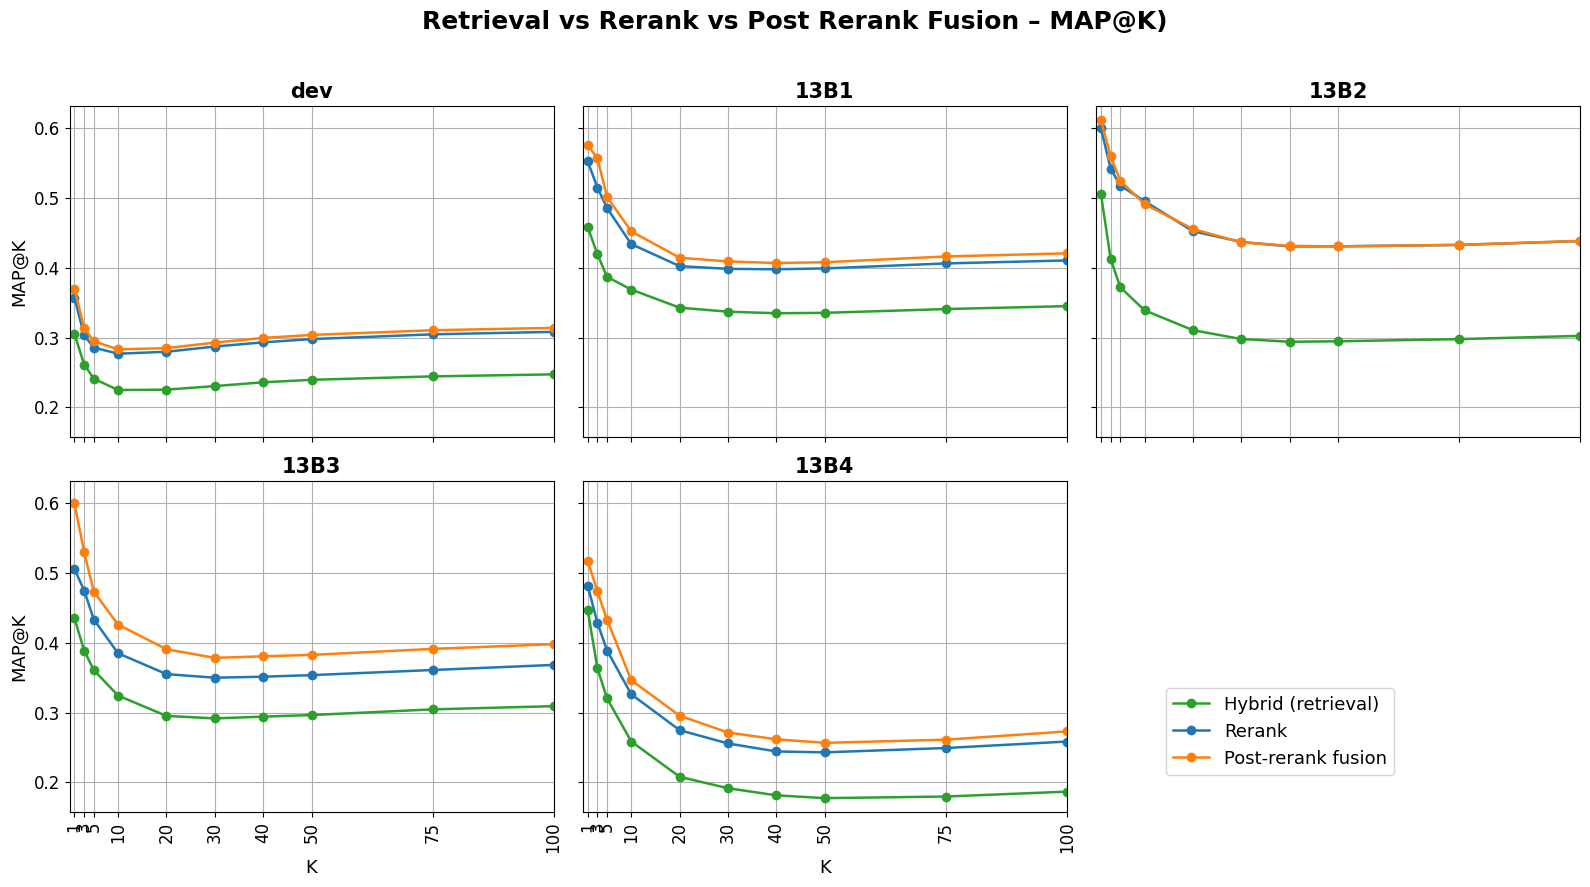

In [17]:
from collections import defaultdict

map_ks = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]


def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels(path: Path) -> dict[str, set[str]]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    qrels: dict[str, set[str]] = {}
    for q in data.get("questions", []):
        qid = str(q.get("id"))
        docs = q.get("documents", [])
        pmids = {
            _extract_pmid(d)
            for d in docs
            if _extract_pmid(d)
        }
        if qid and pmids:
            qrels[qid] = pmids
    return qrels


def _load_run(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _ap_at_k(docs: list[str], rels: set[str], k: int) -> float:
    """BioASQ-style AP@k, matching retrieval_eval.common.ap_at_k."""
    if not rels:
        return 0.0
    denom = min(len(rels), k)
    if denom == 0:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            hits += 1
            score += hits / i
    return score / denom


def _map_at_ks_for_run(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_ap_at_k(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}


qrels_paths = {
    "training14b_10pct_sample": base_dir / "example" / "training14b_10pct_sample.json",
    "13B1_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
}

qrels_by_split = {s: _load_qrels(p) for s, p in qrels_paths.items()}

run_dirs = {
    "Hybrid (retrieval)": workflow_dir / "hybrid" / "runs",
    "Rerank": workflow_dir / "rerank" / "runs",
    "Post-rerank fusion": workflow_dir / "rerank_hybrid_200" / "runs",
}

map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits:
    qrels_split = qrels_by_split.get(split, {})
    for method_name, runs_dir in run_dirs.items():
        # Hybrid and rerank use simple pattern; fusion has extra suffix but same prefix.
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        map_vals = _map_at_ks_for_run(run_df, qrels_split, map_ks)
        map_curves[method_name][split] = map_vals

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes_flat = list(axes.flat)

all_maps = []
for method_dict in map_curves.values():
    for split_vals in method_dict.values():
        all_maps.extend(split_vals.values())

if all_maps:
    y_min = max(0.0, min(all_maps) - 0.02)
    y_max = min(1.0, max(all_maps) + 0.02)
else:
    y_min, y_max = 0.0, 1.0

colors_map = {
    "Hybrid (retrieval)": "#2ca02c",
    "Rerank": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

for idx, split in enumerate(splits):
    ax = axes_flat[idx]
    for method_name, method_dict in map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            vals,
            marker="o",
            color=colors_map.get(method_name),
            label=method_name,
            linewidth=1.8,
        )
    ax.set_title(split_labels.get(split, split), fontsize=15, fontweight="bold")
    ax.set_ylim(y_min, y_max)

    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    else:
        ax.set_ylabel("")

    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(map_ks)
        ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

for j in range(len(splits), len(axes_flat)):
    axes_flat[j].remove()

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.88, 0.12), fontsize=13)

fig.suptitle("Retrieval vs Rerank vs Post Rerank Fusion – MAP@K)", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = output_dir / "04_hybrid_rerank_fusion_mapk_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/04b_hybrid_rerank_fusion_mapk_dev_vs_test_merged.png


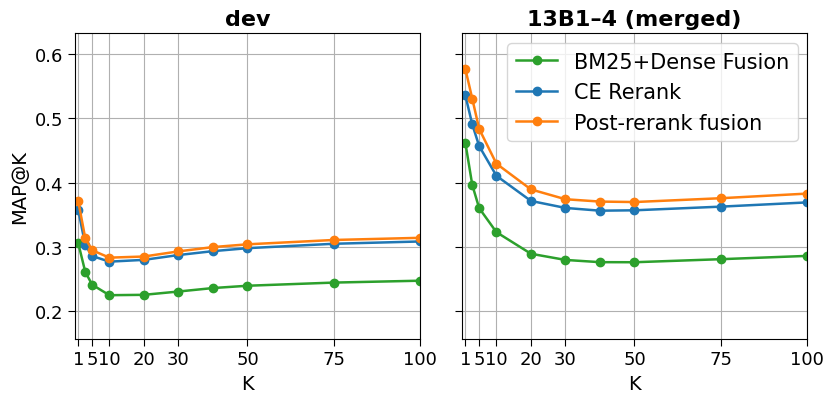

In [21]:
_wn_mapk_x4b = _wn_mapk_xticks(map_ks)
_wn_method_labels_04b = {
    "Hybrid (retrieval)": "BM25+Dense Fusion",
    "Rerank": "CE Rerank",
}
with plt.rc_context(WORKINGNOTE_FIG_RC):
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.2), sharex=True, sharey=True)

    for idx, (panel_label, panel_splits) in enumerate([
        ("dev", ["training14b_10pct_sample"]),
        ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
    ]):
        ax = axes[idx]
        for method_name, method_dict in map_curves.items():
            all_vals = []
            for s in panel_splits:
                if s in method_dict:
                    all_vals.append([method_dict[s].get(k, 0.0) for k in map_ks])
            if not all_vals:
                continue
            vals = np.mean(all_vals, axis=0)
            ax.plot(
                map_ks,
                vals,
                marker="o",
                markersize=6,
                color=colors_map.get(method_name),
                label=_wn_method_labels_04b.get(method_name, method_name),
                linewidth=1.8,
            )
        ax.set_title(panel_label, fontsize=16, fontweight="bold")
        ax.set_ylim(y_min, y_max)
        if idx == 0:
            ax.set_ylabel("MAP@K")
        ax.set_xlabel("K")
        ax.set_xticks(_wn_mapk_x4b)
        ax.set_xticklabels([str(k) for k in _wn_mapk_x4b])
        ax.set_xlim(0, 100)
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.96, 0.9), fontsize=15)
    plt.tight_layout()

fig_path = output_dir / "04b_hybrid_rerank_fusion_mapk_dev_vs_test_merged.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 7. Gold Count Histogram per Query (Dev + Test Combined)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/05_gold_count_hist_all.png


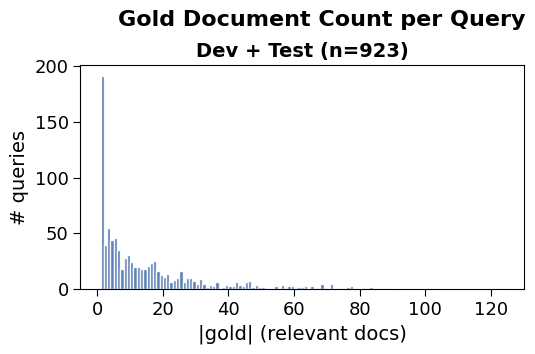

In [51]:
dev_split = "training14b_10pct_sample"
test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]

gold_counts_all = [len(v) for v in qrels_by_split[dev_split].values()]
for s in test_splits:
    gold_counts_all.extend(len(v) for v in qrels_by_split[s].values())

max_gold = max(gold_counts_all) if gold_counts_all else 0
bins = range(1, max_gold + 2) if max_gold > 0 else [0, 1]

with plt.rc_context(WORKINGNOTE_FIG_RC):
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.hist(gold_counts_all, bins=bins, color="#4c72b0", alpha=0.9, edgecolor="white")
    ax.set_xlabel("|gold| (relevant docs)")
    ax.set_ylabel("# queries")
    ax.set_title(f"Dev + Test (n={len(gold_counts_all)})", fontweight="bold",fontsize=14)
    fig.suptitle("Gold Document Count per Query", fontsize=16, fontweight="bold", x=0.6,y=0.88)
    plt.tight_layout(rect=[0, 0, 1, 0.94])

fig_path = output_dir / "05_gold_count_hist_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 8. MAP@K Stratified by Gold Count (All Splits; |gold| = 1, 2, 3–5, >5)

Per-query AP@K rows: 27690
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/06_mapk_by_gold_bucket_all.png


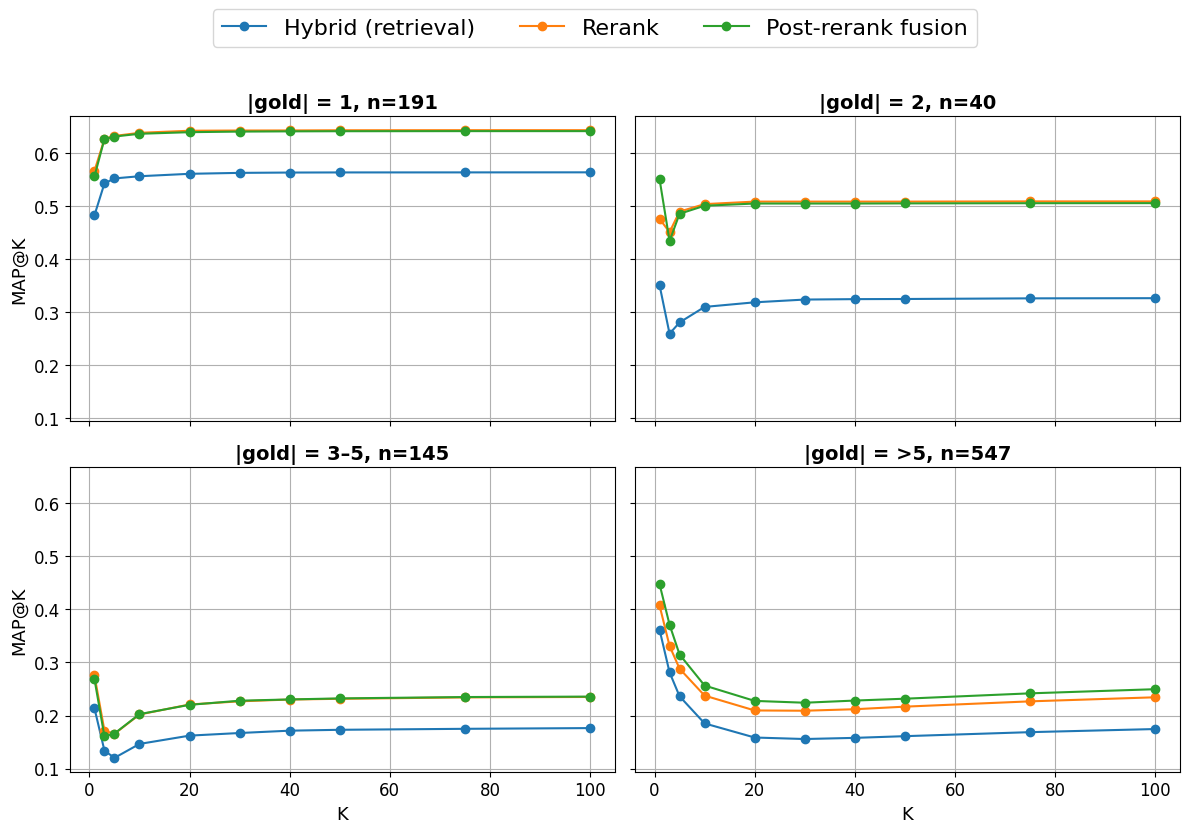

In [55]:
bucket_order = ["1", "2", "3–5", ">5"]


def _gold_bucket(n: int) -> str:
    if n == 1:
        return "1"
    if n == 2:
        return "2"
    if 3 <= n <= 5:
        return "3–5"
    return ">5"


records = []
for method_name, runs_dir in run_dirs.items():
    for split in [dev_split] + test_splits:
        qrels_split = qrels_by_split[split]
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)

        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels_split.get(str(qid))
            if not rels:
                continue
            gold_n = len(rels)
            bucket = _gold_bucket(gold_n)
            docs = group[doc_col].tolist()
            for k in map_ks:
                ap = _ap_at_k(docs, set(rels), k)
                records.append(
                    {
                        "split": split,
                        "method": method_name,
                        "qid": str(qid),
                        "gold_n": gold_n,
                        "bucket": bucket,
                        "k": k,
                        "AP@K": ap,
                    }
                )

map_pq_df = pd.DataFrame(records)
print("Per-query AP@K rows:", len(map_pq_df))

# Compute MAP@K aggregated over all splits
summary = (
    map_pq_df.groupby(["method", "bucket", "k"], as_index=False)["AP@K"]
    .mean()
    .rename(columns={"AP@K": "MAP@K"})
)

# Compute per-bucket sample sizes (unique queries)
bucket_counts = (
    map_pq_df[["qid", "bucket"]]
    .drop_duplicates()
    .groupby("bucket")["qid"]
    .nunique()
    .to_dict()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes_flat = axes.flat

for idx, bucket in enumerate(bucket_order):
    ax = axes_flat[idx]
    bucket_df = summary[summary["bucket"] == bucket]
    if bucket_df.empty:
        ax.set_visible(False)
        continue
    for method_name in run_dirs.keys():
        m_df = bucket_df[bucket_df["method"] == method_name]
        if m_df.empty:
            continue
        ax.plot(
            m_df["k"],
            m_df["MAP@K"],
            marker="o",
            label=method_name,
        )
    n_bucket = bucket_counts.get(bucket, 0)
    ax.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 2 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 2:
        ax.set_xlabel("K")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(run_dirs), bbox_to_anchor=(0.5, 1.05), fontsize=16)

#fig.suptitle("MAP@K by Gold Count – Dev + Test Combined", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "06_mapk_by_gold_bucket_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/06b_mapk_recall_by_gold_bucket_all.png


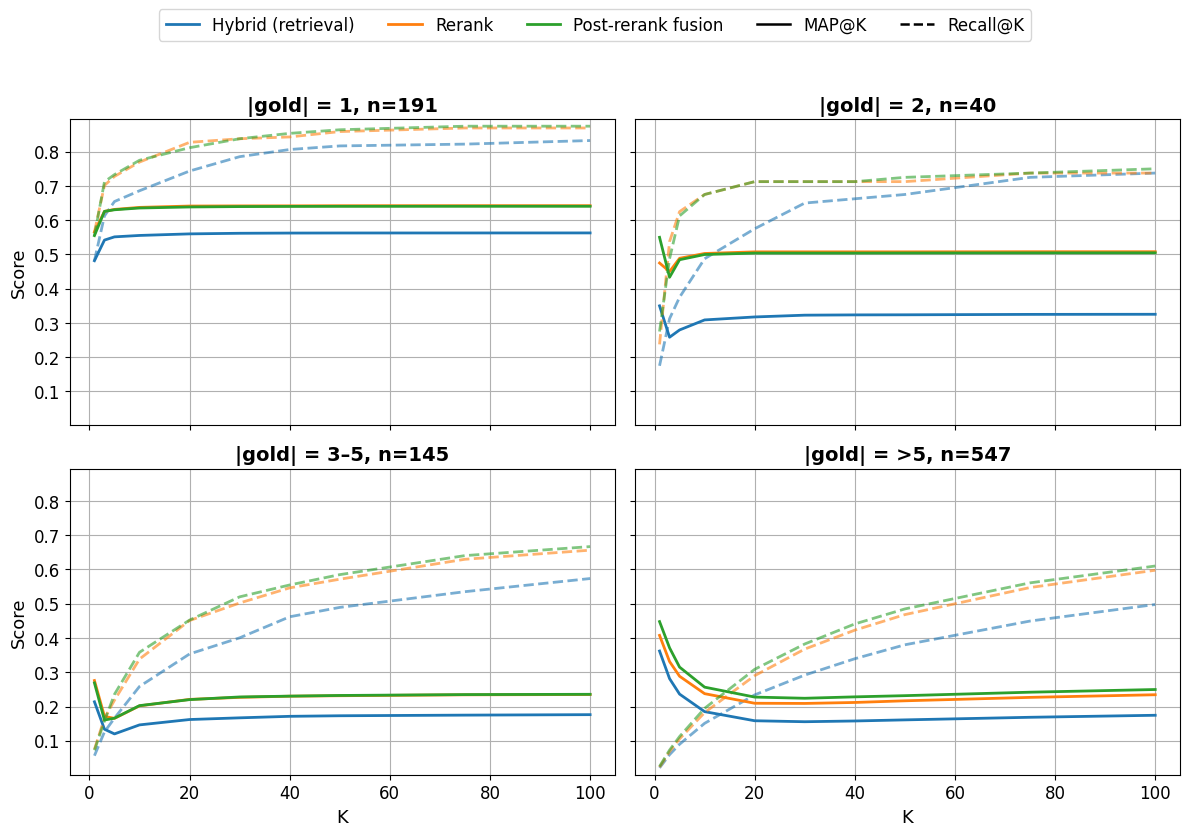

In [56]:
def _recall_at_k(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    hits = sum(1 for d in docs[:k] if d in rels)
    return hits / len(rels)

recall_records = []
for method_name, runs_dir in run_dirs.items():
    for split in [dev_split] + test_splits:
        qrels_split = qrels_by_split[split]
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels_split.get(str(qid))
            if not rels:
                continue
            docs = group[doc_col].tolist()
            bucket = _gold_bucket(len(rels))
            for k in map_ks:
                recall_records.append({
                    "method": method_name,
                    "bucket": bucket,
                    "k": k,
                    "Recall@K": _recall_at_k(docs, set(rels), k),
                })

recall_pq_df = pd.DataFrame(recall_records)
recall_summary = (
    recall_pq_df.groupby(["method", "bucket", "k"], as_index=False)["Recall@K"]
    .mean()
)

combined = summary.merge(recall_summary, on=["method", "bucket", "k"], how="outer")

all_vals = list(combined["MAP@K"].dropna()) + list(combined["Recall@K"].dropna())
y_min_c = max(0.0, min(all_vals) - 0.02) if all_vals else 0.0
y_max_c = min(1.0, max(all_vals) + 0.02) if all_vals else 1.0

method_colors = {name: f"C{i}" for i, name in enumerate(run_dirs)}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes_flat = axes.flat

for idx, bucket in enumerate(bucket_order):
    ax = axes_flat[idx]
    bucket_df = combined[combined["bucket"] == bucket]
    if bucket_df.empty:
        ax.set_visible(False)
        continue
    for method_name in run_dirs:
        m_df = bucket_df[bucket_df["method"] == method_name].sort_values("k")
        if m_df.empty:
            continue
        c = method_colors[method_name]
        # Solid line for MAP@K
        ax.plot(
            m_df["k"],
            m_df["MAP@K"],
            color=c,
            linewidth=2.0,
        )
        # Dashed, semi-transparent line for Recall@K
        ax.plot(
            m_df["k"],
            m_df["Recall@K"],
            color=c,
            linewidth=2.0,
            linestyle="--",
            alpha=0.6,
        )
    n_bucket = bucket_counts.get(bucket, 0)
    ax.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
    ax.set_ylim(y_min_c, y_max_c)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 2 == 0:
        ax.set_ylabel("Score")
    if idx >= 2:
        ax.set_xlabel("K")

from matplotlib.lines import Line2D
method_handles = [
    Line2D([], [], color=method_colors[m], linewidth=2.0, label=m)
    for m in run_dirs
]
style_handles = [
    Line2D([], [], color="black", linewidth=1.8, linestyle="-", label="MAP@K"),
    Line2D([], [], color="black", linewidth=1.8, linestyle="--", label="Recall@K"),
]
fig.legend(
    handles=method_handles + style_handles,
    loc="upper center",
    ncol=len(run_dirs) + 2,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "06b_mapk_recall_by_gold_bucket_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 8c. Working-note figure: MAP@K (top) and Recall@K (bottom) by |gold| bucket
Merged version used in the working note. 2 rows × 4 cols: MAP@K and Recall@K
for each |gold| bucket {1, 2, 3–5, >5}. Reuses `summary` and `recall_summary`
computed above so no extra IO is needed.

Saved (workingnotes): /Users/yun/develop/BioASQ/workingnotes/figures/07_mapk_recall_by_gold_bucket.png


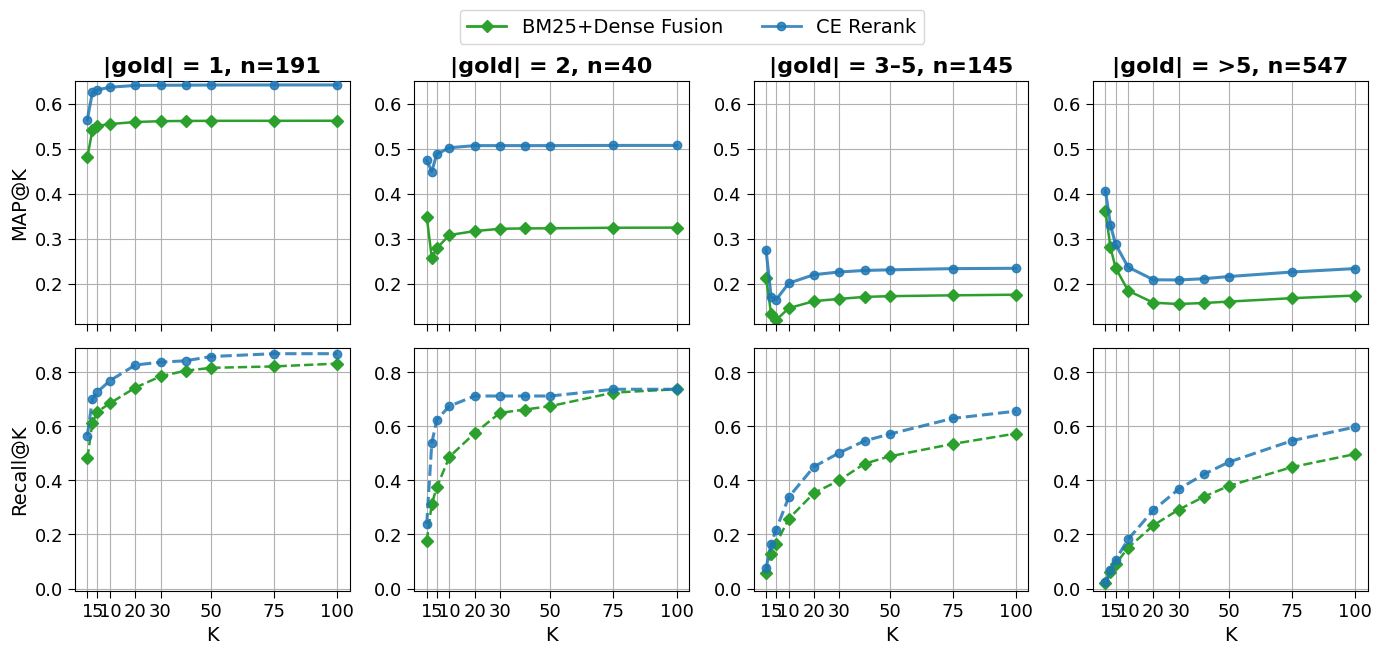

In [85]:
_wn_mapk_x8c = _wn_mapk_xticks(map_ks)
with plt.rc_context(WORKINGNOTE_FIG_RC):
    fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), sharex=True)
    methods_gold = [m for m in run_dirs if m != "Post-rerank fusion"]
    # Match the color scheme used in figs 01/02b/03/04b:
    # BM25+Dense Fusion = green, CE Rerank = blue.
    colors_gold = {
        "Hybrid (retrieval)": "#2ca02c",
        "Rerank": "#1f77b4",
    }
    labels_gold = {
        "Hybrid (retrieval)": "BM25+Dense Fusion",
        "Rerank": "CE Rerank",
    }
    style_gold = {
        "Hybrid (retrieval)": {"marker": "D", "alpha": 1.0, "linewidth": 1.8, "zorder": 2},
        "Rerank": {"marker": "o", "alpha": 0.85, "linewidth": 2.2, "zorder": 3},
    }

    for col, bucket in enumerate(bucket_order):
        n_bucket = bucket_counts.get(bucket, 0)

        ax_top = axes[0, col]
        for method_name in methods_gold:
            sub = (
                summary[(summary["bucket"] == bucket) & (summary["method"] == method_name)]
                .sort_values("k")
            )
            if sub.empty:
                continue
            st = style_gold[method_name]
            ax_top.plot(
                sub["k"],
                sub["MAP@K"],
                marker=st["marker"],
                markersize=6,
                color=colors_gold[method_name],
                linewidth=st["linewidth"],
                alpha=st["alpha"],
                zorder=st["zorder"],
                label=labels_gold[method_name],
            )
        ax_top.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
        if col == 0:
            ax_top.set_ylabel("MAP@K")
        ax_top.set_xticks(_wn_mapk_x8c)
        ax_top.set_xticklabels([str(k) for k in _wn_mapk_x8c])
        ax_top.grid(True, axis="y")
        ax_top.grid(True, axis="x")

        ax_bot = axes[1, col]
        for method_name in methods_gold:
            sub = (
                recall_summary[
                    (recall_summary["bucket"] == bucket)
                    & (recall_summary["method"] == method_name)
                ]
                .sort_values("k")
            )
            if sub.empty:
                continue
            st = style_gold[method_name]
            ax_bot.plot(
                sub["k"],
                sub["Recall@K"],
                marker=st["marker"],
                markersize=6,
                linestyle="--",
                color=colors_gold[method_name],
                linewidth=st["linewidth"],
                alpha=st["alpha"],
                zorder=st["zorder"],
            )
        if col == 0:
            ax_bot.set_ylabel("Recall@K")
        ax_bot.set_xlabel("K")
        ax_bot.set_xticks(_wn_mapk_x8c)
        ax_bot.set_xticklabels([str(k) for k in _wn_mapk_x8c])
        ax_bot.grid(True, axis="y")
        ax_bot.grid(True, axis="x")

    # Share Y within each row only (MAP vs Recall have different scales)
    for row in (0, 1):
        row_axes = list(axes[row])
        ymin = min(a.get_ylim()[0] for a in row_axes)
        ymax = max(a.get_ylim()[1] for a in row_axes)
        for a in row_axes:
            a.set_ylim(ymin, ymax)

    from matplotlib.lines import Line2D as _Line2D_gold
    legend_handles_gold = [
        _Line2D_gold(
            [], [],
            color=colors_gold[m],
            marker=style_gold[m]["marker"],
            markersize=6,
            linewidth=2.0,
            alpha=style_gold[m]["alpha"],
            label=labels_gold[m],
        )
        for m in methods_gold
    ]
    fig.legend(
        handles=legend_handles_gold,
        loc="upper center",
        ncol=len(methods_gold),
        bbox_to_anchor=(0.5, 1.02),
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])

fig_path_wn = wn_output_dir / "07_mapk_recall_by_gold_bucket.png"
plt.savefig(fig_path_wn, dpi=150, bbox_inches="tight")
print("Saved (workingnotes):", fig_path_wn)
plt.show()

## 9. MAP@K Curves – Rerankers Across Configs (Train + Test Splits)
Note: for the train/dev split we drop any queries whose IDs also appear in the
test batches (13B1–4) to avoid training/eval overlap.

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/07_rerankers_mapk_test_splits.png


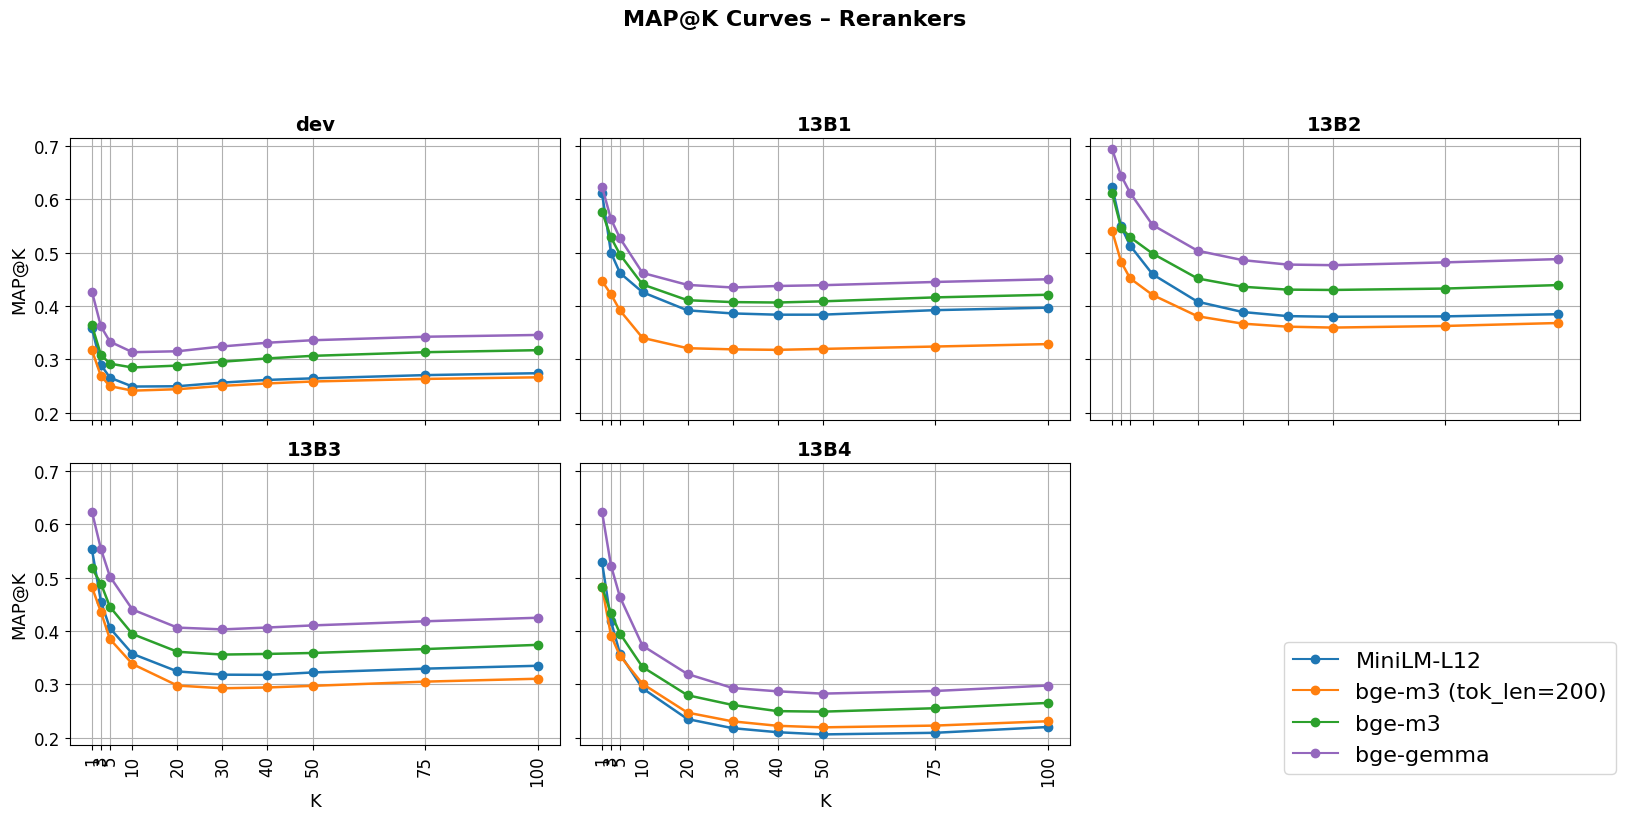

In [80]:
map_ks = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]

splits_rerank = [
    "training14b_10pct_sample",
    "13B1_golden",
    "13B2_golden",
    "13B3_golden",
    "13B4_golden",
]

rerank_only_run_dirs = {
    "ms-marco-MiniLM-L-12-v2, 33.4M": base_dir / "output" / "eval_stage2_rerank_miniLM" / "runs",
    "bge-reranker-v2-m3, 568M, tok_len=200": base_dir / "output" / "eval_stage2_rerank_bge_reranker_v2_m3_len200" / "runs",
    "bge-reranker-v2-m3, 568M": base_dir / "output" / "eval_stage2_rerank_bge_reranker_v2_m3_len512" / "runs",
    "bge-reranker-v2-gemma, 2.5B": base_dir / "output" / "workflow_baseline_full_run_both_routes_gemma" / "rerank" / "runs",
}

# Precompute overlapping qids between train and test splits based on rerank runs.
# We use the MiniLM runs as the canonical source of which train queries overlap
# with the 13B1–4 test batches, then exclude those qids from all train analyses.
train_split_id = "training14b_10pct_sample"
test_split_ids = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
train_overlap_qids: set[str] = set()

minilm_runs_dir = rerank_only_run_dirs["ms-marco-MiniLM-L-12-v2, 33.4M"]

# Train run: best_rrf_train_subset_top*.tsv
train_candidates = list((minilm_runs_dir).glob("best_rrf_train_subset_top*.tsv"))
if train_candidates:
    train_run_df = _load_run(train_candidates[0])
    train_qid_col, _ = train_run_df.columns.tolist()
    train_qids_run = set(train_run_df[train_qid_col].astype(str).tolist())
else:
    train_qids_run = set()

test_qids_run: set[str] = set()
for s in test_split_ids:
    test_candidates = list((minilm_runs_dir).glob(f"best_rrf_{s}_top*.tsv"))
    if not test_candidates:
        continue
    test_run_df = _load_run(test_candidates[0])
    qid_col, _ = test_run_df.columns.tolist()
    test_qids_run.update(test_run_df[qid_col].astype(str).tolist())

train_overlap_qids = train_qids_run & test_qids_run

rerank_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    for method_name, runs_dir in rerank_only_run_dirs.items():
        # Train/dev filenames use different stems ("train_subset" vs "training14b_10pct_sample")
        # across reranker outputs, so try both patterns for that split.
        stems = [split]
        if split == "training14b_10pct_sample":
            stems = ["train_subset", split]

        run_path = None
        for stem in stems:
            pattern = f"best_rrf_{stem}_top"
            candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
            if candidates:
                run_path = candidates[0]
                break

        if run_path is None:
            continue

        run_df = _load_run(run_path)

        # For train/dev, drop any qids that overlap with test batches.
        if split == train_split_id and train_overlap_qids:
            qid_col, _ = run_df.columns.tolist()
            run_df = run_df[~run_df[qid_col].astype(str).isin(train_overlap_qids)]

        map_vals = _map_at_ks_for_run(run_df, qrels_split, map_ks)
        rerank_map_curves[method_name][split] = map_vals

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes_flat = list(axes.flat)

all_vals = []
for method_dict in rerank_map_curves.values():
    for split_vals in method_dict.values():
        all_vals.extend(split_vals.values())

if all_vals:
    y_min = max(0.0, min(all_vals) - 0.02)
    y_max = min(1.0, max(all_vals) + 0.02)
else:
    y_min, y_max = 0.0, 1.0

colors_rerank = {
    "ms-marco-MiniLM-L-12-v2, 33.4M": "#1f77b4",
    "bge-reranker-v2-m3, 568M, tok_len=200": "#ff7f0e",
    "bge-reranker-v2-m3, 568M": "#2ca02c",
    "bge-reranker-v2-gemma, 2.5B": "#9467bd",
}

# Short legend labels (full keys stay as dict keys for IO / colors).
RERANK_MODEL_LEGEND_SHORT = {
    "ms-marco-MiniLM-L-12-v2, 33.4M": "MiniLM-L12",
    "bge-reranker-v2-m3, 568M, tok_len=200": "bge-m3 (tok_len=200)",
    "bge-reranker-v2-m3, 568M": "bge-m3",
    "bge-reranker-v2-gemma, 2.5B": "bge-gemma",
}

for idx, split in enumerate(splits_rerank):
    ax = axes_flat[idx]
    for method_name, method_dict in rerank_map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            vals,
            marker="o",
            linewidth=1.8,
            color=colors_rerank[method_name],
            label=RERANK_MODEL_LEGEND_SHORT.get(method_name, method_name),
        )
    ax.set_title(split_labels.get(split, split), fontsize=14, fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(map_ks)
        ax.set_xticklabels([str(k) for k in map_ks], rotation=90)

# Remove unused 6th panel so it doesn't show
for j in range(len(splits_rerank), len(axes_flat)):
    axes_flat[j].remove()

from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0],
        [0],
        color=colors_rerank[name],
        marker="o",
        linestyle="-",
        label=RERANK_MODEL_LEGEND_SHORT.get(name, name),
    )
    for name in colors_rerank.keys()
]
fig.legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(1.02, 0.05),
    fontsize=16,
)
fig.suptitle("MAP@K Curves – Rerankers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "07_rerankers_mapk_test_splits.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/07b_rerankers_mapk_dev_vs_test_merged.png


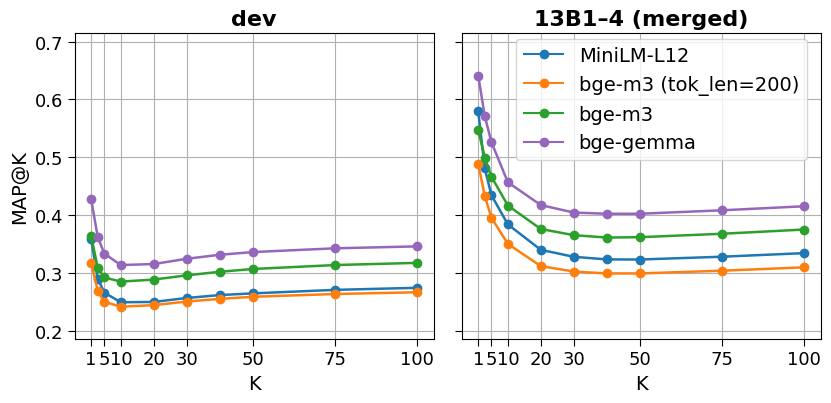

In [83]:
_wn_mapk_x7b = _wn_mapk_xticks(map_ks)
with plt.rc_context(WORKINGNOTE_FIG_RC):
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.2), sharex=True, sharey=True)

    for idx, (panel_label, panel_splits) in enumerate([
        ("dev", ["training14b_10pct_sample"]),
        ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
    ]):
        ax = axes[idx]
        for method_name, method_dict in rerank_map_curves.items():
            all_vals = []
            for s in panel_splits:
                if s in method_dict:
                    all_vals.append([method_dict[s].get(k, 0.0) for k in map_ks])
            if not all_vals:
                continue
            vals = np.mean(all_vals, axis=0)
            ax.plot(
                map_ks,
                vals,
                marker="o",
                markersize=6,
                linewidth=1.8,
                color=colors_rerank[method_name],
                label=RERANK_MODEL_LEGEND_SHORT.get(method_name, method_name),
            )
        ax.set_title(panel_label, fontsize=16, fontweight="bold")
        ax.set_ylim(y_min, y_max)
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")
        if idx == 0:
            ax.set_ylabel("MAP@K")
        ax.set_xlabel("K")
        ax.set_xticks(_wn_mapk_x7b)
        ax.set_xticklabels([str(k) for k in _wn_mapk_x7b])

    legend_handles_c = [
        Line2D(
            [0],
            [0],
            color=colors_rerank[name],
            marker="o",
            linestyle="-",
            label=RERANK_MODEL_LEGEND_SHORT.get(name, name),
        )
        for name in colors_rerank.keys()
    ]
    fig.legend(
        handles=legend_handles_c,
        loc="upper right",
        bbox_to_anchor=(0.97, 0.91),
        fontsize=14,
    )
    plt.tight_layout()

fig_path = output_dir / "07b_rerankers_mapk_dev_vs_test_merged.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 10. MedCPT – MAP@K Curves: `rerank_hybrid_200` vs `snippet_rerank`

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/08_medcpt_rerank/post_rerank_fusion200_vs_snippet_mapk.png


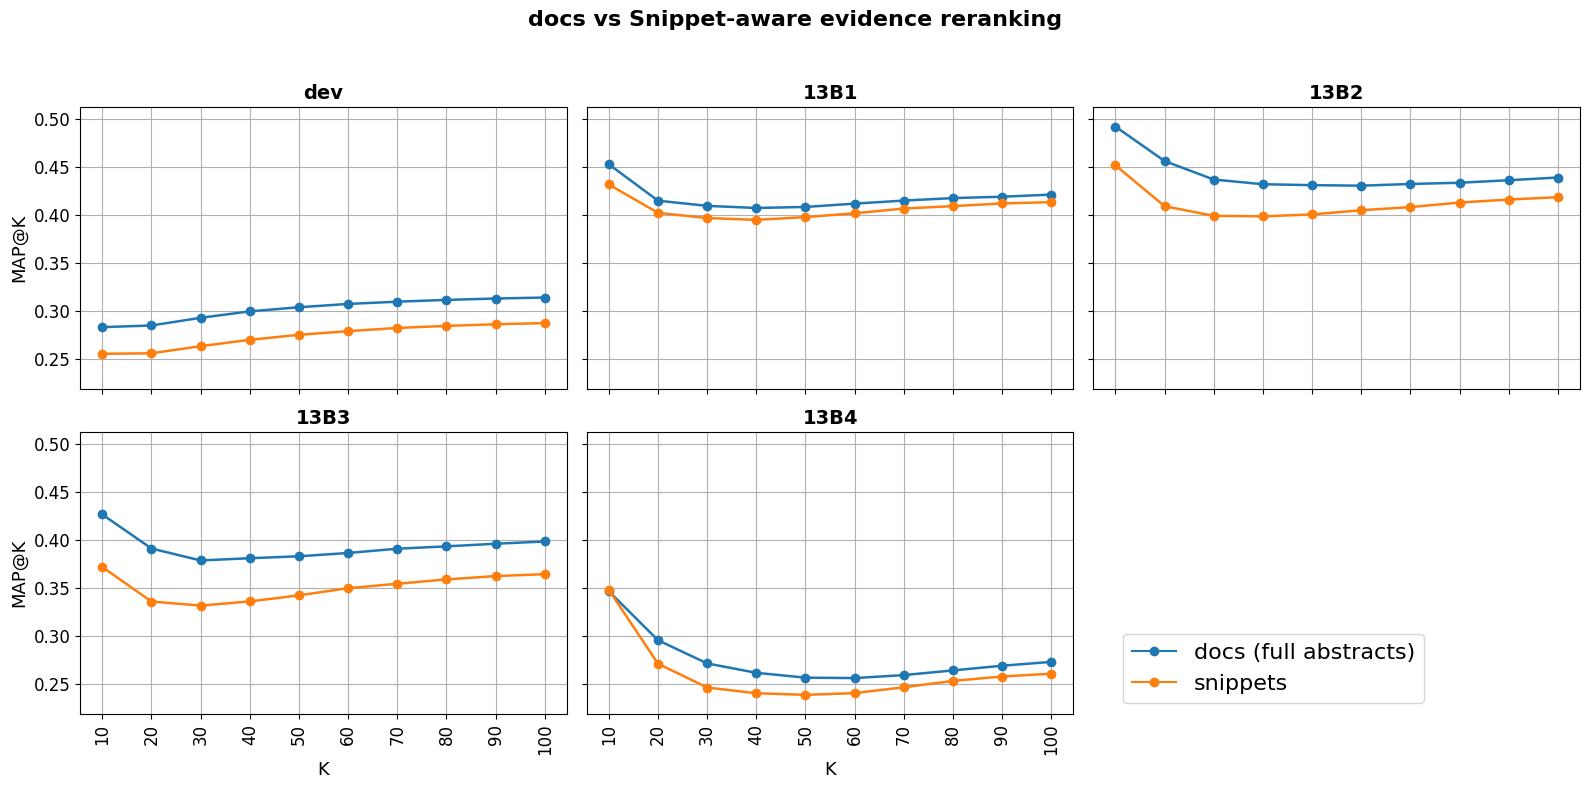

In [68]:
medcpt_dir = base_dir / "output" / "workflow_baseline_full_run_both_routes_MedCPT"

medcpt_run_dirs = {
    "docs (full abstracts)": medcpt_dir / "rerank_hybrid_200" / "runs",
    "snippets": medcpt_dir / "snippet_rerank" / "runs",
}

medcpt_map_ks = list(range(10, 101, 10))

(output_dir / "08_medcpt_rerank").mkdir(parents=True, exist_ok=True)
(output_dir / "08b_medcpt_rerank").mkdir(parents=True, exist_ok=True)

medcpt_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    for method_name, runs_dir in medcpt_run_dirs.items():
        stem = f"best_rrf_{split}_top5000_rrf_poolR200_poolH200_k60"
        run_path = runs_dir / f"{stem}.tsv"
        if not run_path.exists():
            continue
        run_df = _load_run(run_path)
        # For train/dev, drop any qids that overlap with test batches (same logic as section 9).
        if split == "training14b_10pct_sample" and train_overlap_qids:
            qid_col, _ = run_df.columns.tolist()
            run_df = run_df[~run_df[qid_col].astype(str).isin(train_overlap_qids)]
        map_vals = _map_at_ks_for_run(run_df, qrels_split, medcpt_map_ks)
        medcpt_map_curves[method_name][split] = map_vals

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes_flat = list(axes.flat)

all_vals_medcpt: list[float] = []
for method_dict in medcpt_map_curves.values():
    for split_vals in method_dict.values():
        all_vals_medcpt.extend(split_vals.values())

if all_vals_medcpt:
    y_min_m = max(0.0, min(all_vals_medcpt) - 0.02)
    y_max_m = min(1.0, max(all_vals_medcpt) + 0.02)
else:
    y_min_m, y_max_m = 0.0, 1.0

colors_medcpt = {
    "docs (full abstracts)": "#1f77b4",
    "snippets": "#ff7f0e",
}

for idx, split in enumerate(splits_rerank):
    ax = axes_flat[idx]
    for method_name, method_dict in medcpt_map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in medcpt_map_ks]
        ax.plot(
            medcpt_map_ks,
            vals,
            marker="o",
            linewidth=1.8,
            color=colors_medcpt[method_name],
            label=method_name,
        )
    ax.set_title(split_labels.get(split, split), fontsize=14, fontweight="bold")
    ax.set_ylim(y_min_m, y_max_m)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(medcpt_map_ks)
        ax.set_xticklabels([str(k) for k in medcpt_map_ks], rotation=90)

for j in range(len(splits_rerank), len(axes_flat)):
    axes_flat[j].remove()

from matplotlib.lines import Line2D as _Line2D_medcpt

legend_medcpt_handles = [
    _Line2D_medcpt([0], [0], color=colors_medcpt[name], marker="o", linestyle="-", label=name)
    for name in colors_medcpt.keys()
]
fig.legend(
    handles=legend_medcpt_handles,
    labels=list(colors_medcpt.keys()),
    loc="lower right",
    bbox_to_anchor=(0.9, 0.1),
    fontsize=16,
)
fig.suptitle(
    "docs vs Snippet-aware evidence reranking",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "08_medcpt_rerank/post_rerank_fusion200_vs_snippet_mapk.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/08b_medcpt_rerank/post_rerank_fusion200_vs_snippet_mapk_dev_vs_test_merged.png


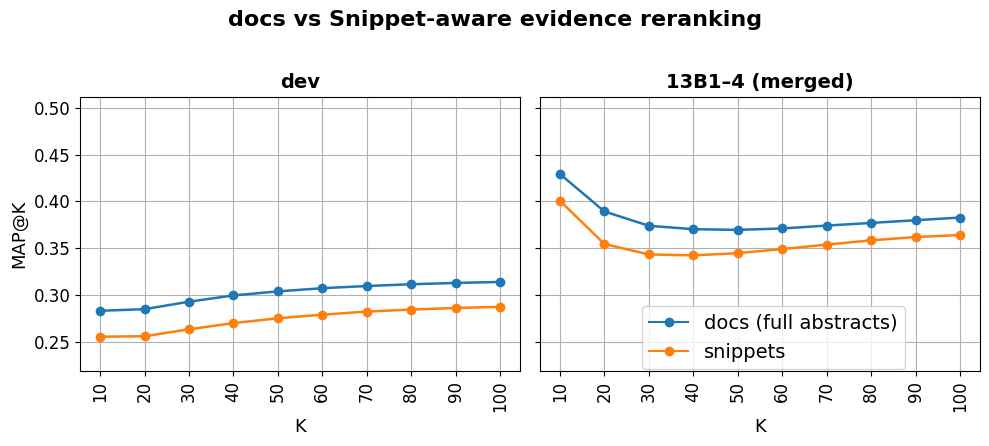

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

for idx, (panel_label, panel_splits) in enumerate([
    ("dev", ["training14b_10pct_sample"]),
    ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
]):
    ax = axes[idx]
    for method_name, method_dict in medcpt_map_curves.items():
        all_vals = []
        for s in panel_splits:
            if s in method_dict:
                all_vals.append([method_dict[s].get(k, 0.0) for k in medcpt_map_ks])
        if not all_vals:
            continue
        vals = np.mean(all_vals, axis=0)
        ax.plot(medcpt_map_ks, vals, marker="o", linewidth=1.8,
                color=colors_medcpt[method_name], label=method_name)
    ax.set_title(panel_label, fontsize=14, fontweight="bold")
    ax.set_ylim(y_min_m, y_max_m)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx == 0:
        ax.set_ylabel("MAP@K")
    ax.set_xlabel("K")
    ax.set_xticks(medcpt_map_ks)
    ax.set_xticklabels([str(k) for k in medcpt_map_ks], rotation=90)

legend_medcpt_handles_c = [
    _Line2D_medcpt([0], [0], color=colors_medcpt[name], marker="o", linestyle="-", label=name)
    for name in colors_medcpt.keys()
]
fig.legend(
    handles=legend_medcpt_handles_c,
    labels=list(colors_medcpt.keys()),
    loc="lower right",
    bbox_to_anchor=(0.92, 0.16),
    fontsize=14,
)
fig.suptitle(
    "docs vs Snippet-aware evidence reranking",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "08b_medcpt_rerank/post_rerank_fusion200_vs_snippet_mapk_dev_vs_test_merged.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 11. MedCPT – RRF Fusion Sweep: MAP@10 vs Weight (rerank_hybrid_200 + snippet_rerank)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/09_medcpt_rrf_fusion_map10_vs_weight.png


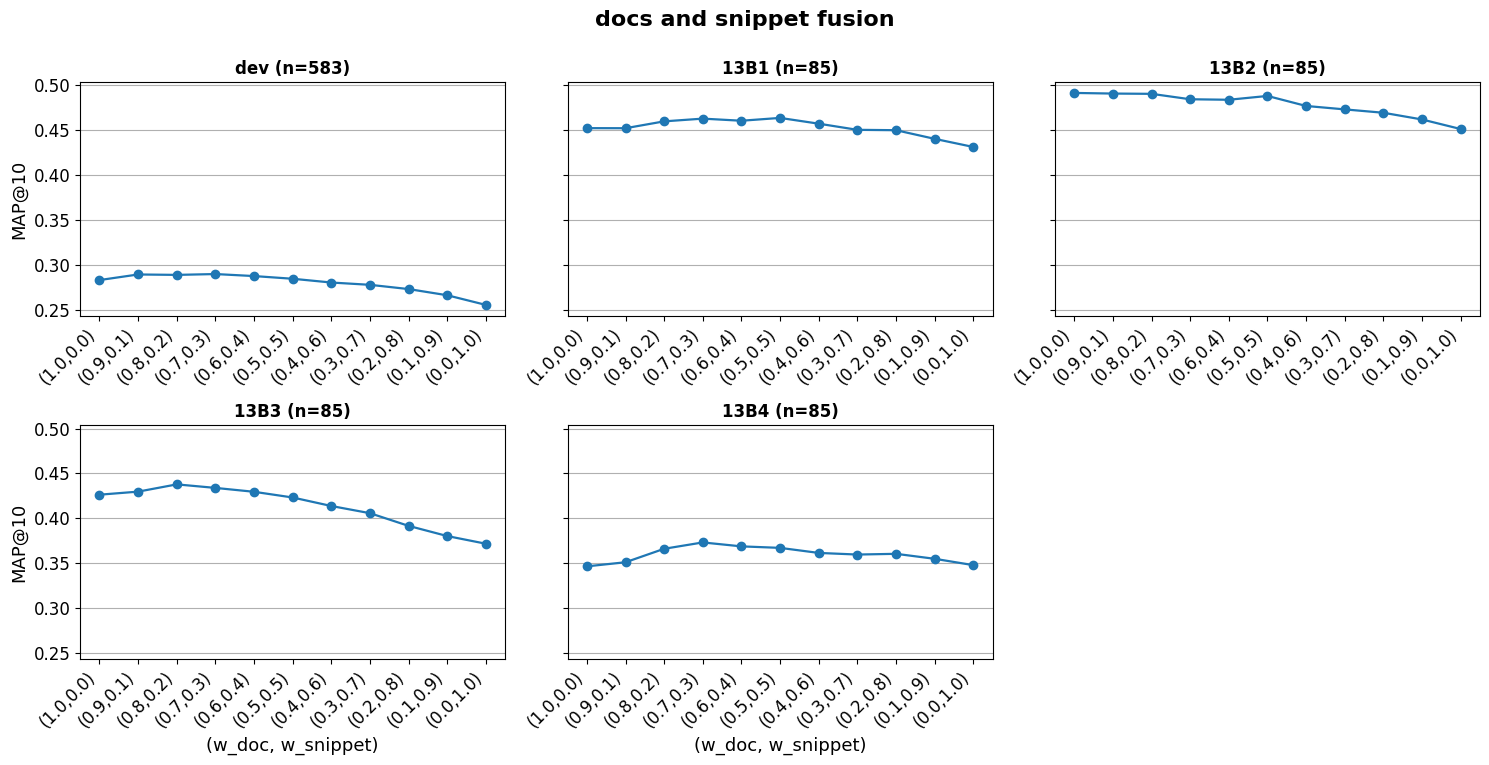

In [70]:
# We reproduce the "MAP@10 vs weight config" line plots from `snippet_extraction_MedCPT.py`,
# but only for our local MedCPT snippet reranker (no external MedCPT_bge-m3 dependency),
# and using the qrels / overlap filtering already defined in this notebook.

RUN_TOP = 100
OUTPUT_TOP = 10
RRF_KS = [60]
RRF_WEIGHTS = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0),
]


def _build_run_map(run_df: pd.DataFrame) -> dict[str, list[str]]:
    qid_col, doc_col = run_df.columns.tolist()
    run_map: dict[str, list[str]] = {}
    for qid, group in run_df.groupby(qid_col, sort=False):
        run_map[str(qid)] = group[doc_col].astype(str).tolist()
    return run_map


def _rrf_fuse_docs(
    docs_hybrid: list[str],
    docs_snippet: list[str],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
    run_top: int,
    output_top: int,
) -> list[str]:
    hybrid_top = docs_hybrid[:run_top]
    snippet_top = docs_snippet[:run_top]
    rank_h = {d: i + 1 for i, d in enumerate(hybrid_top)}
    rank_s = {d: i + 1 for i, d in enumerate(snippet_top)}
    union = list(dict.fromkeys(hybrid_top + snippet_top))
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        rh = rank_h.get(d)
        rs = rank_s.get(d)
        if rh is not None:
            s += w_hybrid / (k_rrf + rh)
        if rs is not None:
            s += w_snippet / (k_rrf + rs)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored[:output_top]]


def _ap10_for_fusion(
    gold: dict[str, list[str]] | dict[str, set[str]],
    run_hybrid: dict[str, list[str]],
    run_snippet: dict[str, list[str]],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
) -> tuple[float, int]:
    # gold is qid -> iterable of relevant doc ids
    qids = [q for q in gold if q in run_hybrid and q in run_snippet and gold[q]]
    if not qids:
        return 0.0, 0
    ap_vals: list[float] = []
    for q in qids:
        rels = set(gold[q])
        fused_docs = _rrf_fuse_docs(
            run_hybrid[q],
            run_snippet[q],
            k_rrf=k_rrf,
            w_hybrid=w_hybrid,
            w_snippet=w_snippet,
            run_top=RUN_TOP,
            output_top=OUTPUT_TOP,
        )
        ap_vals.append(_ap_at_k(fused_docs, rels, k=OUTPUT_TOP))
    return (float(np.mean(ap_vals)) if ap_vals else 0.0, len(qids))


# Build simple gold maps from qrels_by_split (after train/dev overlap filtering).
gold_maps: dict[str, dict[str, set[str]]] = {}
for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    if split == "training14b_10pct_sample" and train_overlap_qids:
        # Drop overlapping qids from train split golds
        gold_maps[split] = {
            qid: rels
            for qid, rels in qrels_split.items()
            if qid not in train_overlap_qids
        }
    else:
        gold_maps[split] = qrels_split

# Load MedCPT hybrid and snippet run maps.
hybrid_run_maps: dict[str, dict[str, list[str]]] = {}
snippet_run_maps: dict[str, dict[str, list[str]]] = {}

for split in splits_rerank:
    # hybrid (rerank_hybrid_200 uses poolR200_poolH200)
    stem_h = f"best_rrf_{split}_top5000_rrf_poolR200_poolH200_k60"
    path_h = (medcpt_dir / "rerank_hybrid_200" / "runs" / f"{stem_h}.tsv")
    # snippet_rerank (same stem/pool config)
    stem_s = f"best_rrf_{split}_top5000_rrf_poolR200_poolH200_k60"
    path_s = (medcpt_dir / "snippet_rerank" / "runs" / f"{stem_s}.tsv")

    if not path_h.exists() or not path_s.exists():
        continue

    df_h = _load_run(path_h)
    df_s = _load_run(path_s)

    if split == "training14b_10pct_sample" and train_overlap_qids:
        qid_col, _ = df_h.columns.tolist()
        mask = ~df_h[qid_col].astype(str).isin(train_overlap_qids)
        df_h = df_h[mask]
        mask = ~df_s[qid_col].astype(str).isin(train_overlap_qids)
        df_s = df_s[mask]

    hybrid_run_maps[split] = _build_run_map(df_h)
    snippet_run_maps[split] = _build_run_map(df_s)

# Sweep weights and compute MAP@10 per split and k_rrf
rrf_rows: list[dict[str, object]] = []

for split in splits_rerank:
    gold = gold_maps.get(split)
    run_h = hybrid_run_maps.get(split)
    run_s = snippet_run_maps.get(split)
    if not gold or not run_h or not run_s:
        continue
    for k_rrf in RRF_KS:
        for w_h, w_s in RRF_WEIGHTS:
            map10, n_q = _ap10_for_fusion(
                gold=gold,
                run_hybrid=run_h,
                run_snippet=run_s,
                k_rrf=k_rrf,
                w_hybrid=w_h,
                w_snippet=w_s,
            )
            rrf_rows.append(
                {
                    "split": split,
                    "k_rrf": k_rrf,
                    "w_hybrid": w_h,
                    "w_snippet": w_s,
                    "MAP@10": map10,
                    "n_queries": n_q,
                }
            )

rrf_results = pd.DataFrame(rrf_rows)
if not rrf_results.empty:
    rrf_results["weight_label"] = rrf_results.apply(
        lambda r: f"({r['w_hybrid']:.1f},{r['w_snippet']:.1f})",
        axis=1,
    )

weight_order = [f"({w[0]:.1f},{w[1]:.1f})" for w in RRF_WEIGHTS]

# Line plot: MAP@10 vs weight config — one line per (k_rrf, snippet_label=MedCPT), one panel per split
if not rrf_results.empty:
    n_splits = rrf_results["split"].nunique()
    n_cols = min(3, n_splits)
    n_rows = (n_splits + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
    if n_splits == 1:
        axes = np.array([axes])
    axes_flat = list(axes.flat)

    for idx, (ax, (split, grp)) in enumerate(zip(axes_flat, rrf_results.groupby("split", sort=False))):
        for k_rrf in sorted(grp["k_rrf"].unique()):
            sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
            vals = sub["MAP@10"].values
            ax.plot(
                range(len(weight_order)),
                vals,
                marker="o",
                linewidth=1.6,
            )
        ax.set_xticks(range(len(weight_order)))
        ax.set_xticklabels(weight_order, rotation=45, ha="right")
        n_q = int(grp["n_queries"].max())
        ax.set_title(f"{split_labels.get(split, split)} (n={n_q})", fontsize=12, fontweight="bold")
        if idx % n_cols == 0:
            ax.set_ylabel("MAP@10")
        if idx >= (n_rows - 1) * n_cols:
            ax.set_xlabel("(w_doc, w_snippet)")
        ax.grid(True, axis="y")
    # Remove any unused axes (e.g. 6th panel in a 2x3 grid)
    for ax in axes_flat[n_splits:]:
        ax.remove()

    fig.suptitle("docs and snippet fusion", fontsize=16, fontweight="bold", y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig_path = output_dir / "09_medcpt_rrf_fusion_map10_vs_weight.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/09b_medcpt_rrf_fusion_map10_vs_weight_dev_vs_test_merged.png


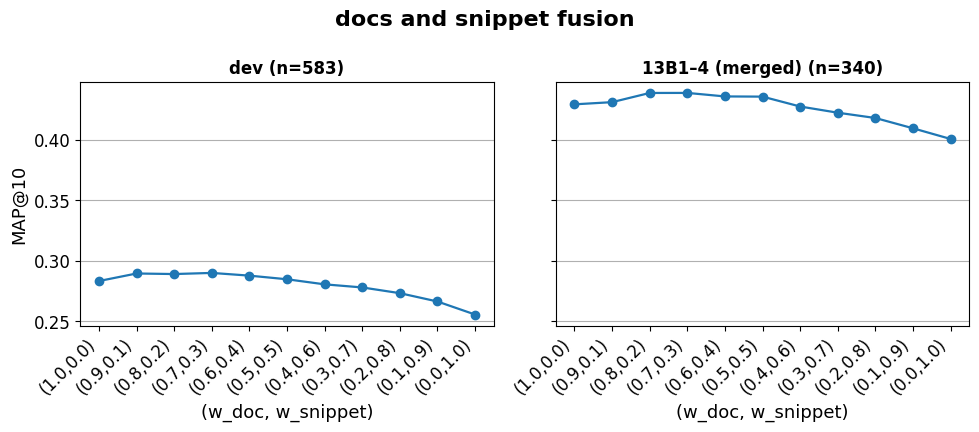

In [71]:
if not rrf_results.empty:
    _test_split_ids_rrf = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
    dev_rrf = rrf_results[rrf_results["split"] == "training14b_10pct_sample"].copy()
    test_rrf = rrf_results[rrf_results["split"].isin(_test_split_ids_rrf)].copy()
    test_rrf_merged = (
        test_rrf.groupby(["k_rrf", "weight_label"], as_index=False)["MAP@10"]
        .mean()
    )
    test_rrf_merged["split"] = "test_merged"
    test_n = test_rrf.groupby(["k_rrf", "weight_label"], as_index=False)["n_queries"].sum()
    test_rrf_merged["n_queries"] = test_n["n_queries"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

    for idx, (panel_label, grp) in enumerate([
        ("dev", dev_rrf),
        ("13B1–4 (merged)", test_rrf_merged),
    ]):
        ax = axes[idx]
        for k_rrf in sorted(grp["k_rrf"].unique()):
            sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
            vals = sub["MAP@10"].values
            ax.plot(range(len(weight_order)), vals, marker="o", linewidth=1.6)
        ax.set_xticks(range(len(weight_order)))
        ax.set_xticklabels(weight_order, rotation=45, ha="right")
        n_q = int(grp["n_queries"].max())
        ax.set_title(f"{panel_label} (n={n_q})", fontsize=12, fontweight="bold")
        if idx == 0:
            ax.set_ylabel("MAP@10")
        ax.set_xlabel("(w_doc, w_snippet)")
        ax.grid(True, axis="y")

    fig.suptitle("docs and snippet fusion", fontsize=16, fontweight="bold", y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig_path = output_dir / "09b_medcpt_rrf_fusion_map10_vs_weight_dev_vs_test_merged.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

## 11c. Historical MedCPT snippet ablation (kept for reference)
Originally the working-note Figure 9; the snippet route now uses bge-m3
throughout (see §11d). This cell still renders the MedCPT-based version
under a `_medcpt` suffix so the historical figure is preserved for
comparison and re-runs do not silently drop it.
2 rows × 2 cols: top row = docs vs snippet MAP@K curves (dev | 13B1–4 merged),
bottom row = doc/snippet weight sweep MAP@10 (dev | 13B1–4 merged).
Reuses `medcpt_map_curves`, `colors_medcpt`, `rrf_results`, `weight_order`.

Saved (workingnotes): /Users/yun/develop/BioASQ/workingnotes/figures/09_snippet_ablation.png


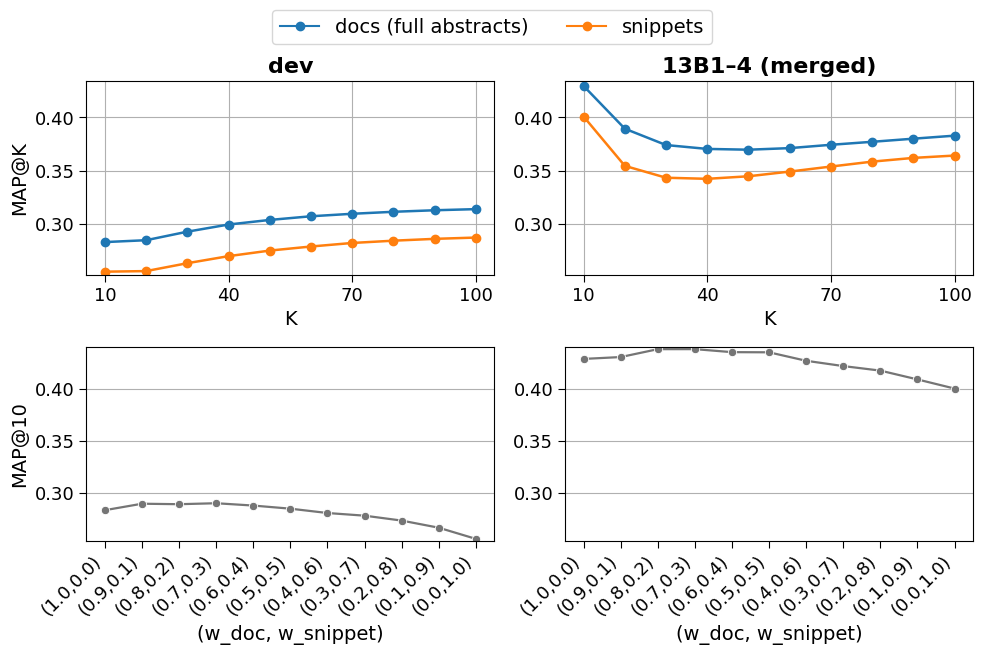

In [73]:
if medcpt_map_curves and not rrf_results.empty:
    _wn_med_x = _wn_medcpt_mapk_xticks(medcpt_map_ks)
    with plt.rc_context(WORKINGNOTE_FIG_RC):
        fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=False)

        # Top row: docs vs snippets MAP@K curves
        for idx, (panel_label, panel_splits) in enumerate([
            ("dev", ["training14b_10pct_sample"]),
            ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
        ]):
            ax = axes[0, idx]
            for method_name, method_dict in medcpt_map_curves.items():
                all_vals = []
                for s in panel_splits:
                    if s in method_dict:
                        all_vals.append([method_dict[s].get(k, 0.0) for k in medcpt_map_ks])
                if not all_vals:
                    continue
                vals = np.mean(all_vals, axis=0)
                ax.plot(
                    medcpt_map_ks,
                    vals,
                    marker="o",
                    markersize=6,
                    linewidth=1.8,
                    color=colors_medcpt[method_name],
                    label=method_name,
                )
            ax.set_title(panel_label, fontsize=16, fontweight="bold")
            if idx == 0:
                ax.set_ylabel("MAP@K")
            ax.set_xlabel("K")
            ax.set_xticks(_wn_med_x)
            ax.set_xticklabels([str(k) for k in _wn_med_x])
            ax.grid(True, axis="y")
            ax.grid(True, axis="x")

        # Bottom row: doc/snippet weight sweep MAP@10 (neutral line color — not top-row “docs” blue)
        _weight_sweep_color = "#757575"
        _test_split_ids_snip = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
        dev_rrf = rrf_results[rrf_results["split"] == "training14b_10pct_sample"].copy()
        test_rrf = rrf_results[rrf_results["split"].isin(_test_split_ids_snip)].copy()
        test_rrf_merged = (
            test_rrf.groupby(["k_rrf", "weight_label"], as_index=False)["MAP@10"].mean()
        )
        _test_n = test_rrf.groupby(["k_rrf", "weight_label"], as_index=False)["n_queries"].sum()
        test_rrf_merged = test_rrf_merged.merge(_test_n, on=["k_rrf", "weight_label"])

        for idx, (_, grp) in enumerate([
            ("dev", dev_rrf),
            ("13B1–4 (merged)", test_rrf_merged),
        ]):
            ax = axes[1, idx]
            for k_rrf in sorted(grp["k_rrf"].unique()):
                sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
                vals = sub["MAP@10"].values
                ax.plot(
                    range(len(weight_order)),
                    vals,
                    marker="o",
                    linewidth=1.6,
                    color=_weight_sweep_color,
                    markerfacecolor=_weight_sweep_color,
                    markeredgecolor="white",
                    markeredgewidth=0.6,
                )
            ax.set_xticks(range(len(weight_order)))
            ax.set_xticklabels(weight_order, rotation=45, ha="right")
            if idx == 0:
                ax.set_ylabel("MAP@10")
            ax.set_xlabel("(w_doc, w_snippet)")
            ax.grid(True, axis="y")

        # Single legend for the docs/snippet line colors (top row)
        from matplotlib.lines import Line2D as _Line2D_snip
        snip_legend = [
            _Line2D_snip([0], [0], color=colors_medcpt[name], marker="o", linestyle="-", label=name)
            for name in colors_medcpt
        ]
        fig.legend(
            handles=snip_legend,
            labels=list(colors_medcpt.keys()),
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(0.5, 1.02),
            fontsize=14,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])

    fig_path_wn = wn_output_dir / "09_snippet_ablation_medcpt.png"
    plt.savefig(fig_path_wn, dpi=150, bbox_inches="tight")
    print("Saved (workingnotes, MedCPT historical):", fig_path_wn)
    plt.show()

## 11d. Working-note Figure 9 (bge-m3 single-model version)
Canonical Fig 9 for the working note. Same 2×2 structure as §11c, but the
snippet rerank uses `bge-reranker-v2-m3` — the same cross-encoder as the
stage-2 doc rerank — so the working note tells a single-model story.
Sources `output/workflow_local_10pct_hpc_bge/` (pool=50, window=3 sentences):
  docs:     rerank_hybrid/runs/best_rrf_{split}_top5000_rrf_pool50_k60.tsv
  snippets: snippet_rerank_windows3/runs/best_rrf_{split}_top5000_rrf_pool50_k60.tsv
Saved to `wn_output_dir / "09_snippet_ablation.png"`.

Saved (workingnotes, bge-m3 canonical): /Users/yun/develop/BioASQ/workingnotes/figures/09_snippet_ablation.png


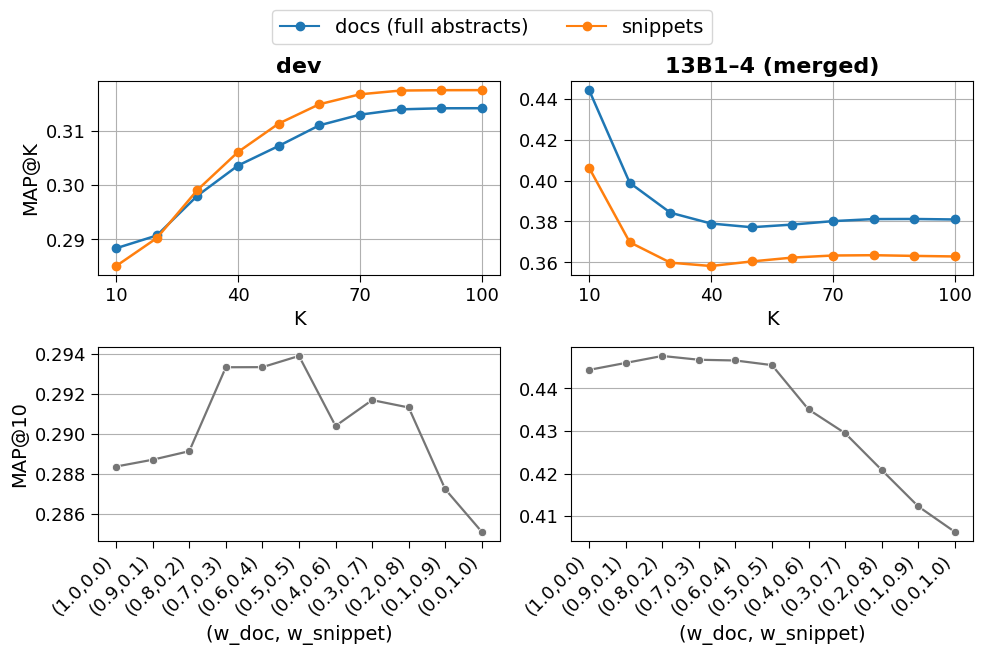

In [98]:
bge_dir = base_dir / "output" / "workflow_local_10pct_hpc_bge"
bge_doc_runs_dir = bge_dir / "rerank_hybrid" / "runs"
bge_snip_runs_dir = bge_dir / "snippet_rerank_windows3" / "runs"
bge_run_dirs = {
    "docs (full abstracts)": bge_doc_runs_dir,
    "snippets": bge_snip_runs_dir,
}

bge_map_ks = list(range(10, 101, 10))
bge_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    if split == "training14b_10pct_sample" and train_overlap_qids:
        qrels_split = {q: r for q, r in qrels_split.items() if q not in train_overlap_qids}
    for method_name, runs_dir in bge_run_dirs.items():
        path = runs_dir / f"best_rrf_{split}_top5000_rrf_pool50_k60.tsv"
        if not path.exists():
            print(f"missing: {path}")
            continue
        run_df = _load_run(path)
        if split == "training14b_10pct_sample" and train_overlap_qids:
            qid_col, _ = run_df.columns.tolist()
            run_df = run_df[~run_df[qid_col].astype(str).isin(train_overlap_qids)]
        bge_map_curves[method_name][split] = _map_at_ks_for_run(run_df, qrels_split, bge_map_ks)

bge_hybrid_run_maps: dict[str, dict[str, list[str]]] = {}
bge_snippet_run_maps: dict[str, dict[str, list[str]]] = {}

for split in splits_rerank:
    path_h = bge_doc_runs_dir / f"best_rrf_{split}_top5000_rrf_pool50_k60.tsv"
    path_s = bge_snip_runs_dir / f"best_rrf_{split}_top5000_rrf_pool50_k60.tsv"
    if not path_h.exists() or not path_s.exists():
        continue
    df_h = _load_run(path_h)
    df_s = _load_run(path_s)
    if split == "training14b_10pct_sample" and train_overlap_qids:
        qid_col, _ = df_h.columns.tolist()
        df_h = df_h[~df_h[qid_col].astype(str).isin(train_overlap_qids)]
        df_s = df_s[~df_s[qid_col].astype(str).isin(train_overlap_qids)]
    bge_hybrid_run_maps[split] = _build_run_map(df_h)
    bge_snippet_run_maps[split] = _build_run_map(df_s)

bge_rrf_rows: list[dict[str, object]] = []
for split in splits_rerank:
    gold = gold_maps.get(split)
    run_h = bge_hybrid_run_maps.get(split)
    run_s = bge_snippet_run_maps.get(split)
    if not gold or not run_h or not run_s:
        continue
    for k_rrf in RRF_KS:
        for w_h, w_s in RRF_WEIGHTS:
            map10, n_q = _ap10_for_fusion(
                gold=gold,
                run_hybrid=run_h,
                run_snippet=run_s,
                k_rrf=k_rrf,
                w_hybrid=w_h,
                w_snippet=w_s,
            )
            bge_rrf_rows.append(
                {
                    "split": split,
                    "k_rrf": k_rrf,
                    "w_hybrid": w_h,
                    "w_snippet": w_s,
                    "MAP@10": map10,
                    "n_queries": n_q,
                }
            )

bge_rrf_results = pd.DataFrame(bge_rrf_rows)
if not bge_rrf_results.empty:
    bge_rrf_results["weight_label"] = bge_rrf_results.apply(
        lambda r: f"({r['w_hybrid']:.1f},{r['w_snippet']:.1f})",
        axis=1,
    )

colors_bge_snip = {
    "docs (full abstracts)": "#1f77b4",
    "snippets": "#ff7f0e",
}

if bge_map_curves and not bge_rrf_results.empty:
    _wn_bge_x = _wn_medcpt_mapk_xticks(bge_map_ks)
    _test_split_ids_bge = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]

    with plt.rc_context(WORKINGNOTE_FIG_RC):
        fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=False)

        # Top row: docs vs snippets MAP@K curves
        for idx, (panel_label, panel_splits) in enumerate([
            ("dev", ["training14b_10pct_sample"]),
            ("13B1–4 (merged)", _test_split_ids_bge),
        ]):
            ax = axes[0, idx]
            for method_name, method_dict in bge_map_curves.items():
                all_vals = []
                for s in panel_splits:
                    if s in method_dict:
                        all_vals.append([method_dict[s].get(k, 0.0) for k in bge_map_ks])
                if not all_vals:
                    continue
                vals = np.mean(all_vals, axis=0)
                ax.plot(
                    bge_map_ks,
                    vals,
                    marker="o",
                    markersize=6,
                    linewidth=1.8,
                    color=colors_bge_snip[method_name],
                    label=method_name,
                )
            ax.set_title(panel_label, fontsize=16, fontweight="bold")
            if idx == 0:
                ax.set_ylabel("MAP@K")
            ax.set_xlabel("K")
            ax.set_xticks(_wn_bge_x)
            ax.set_xticklabels([str(k) for k in _wn_bge_x])
            ax.grid(True, axis="y")
            ax.grid(True, axis="x")

        # Bottom row: doc/snippet weight sweep MAP@10
        _weight_sweep_color = "#757575"
        dev_rrf_bge = bge_rrf_results[bge_rrf_results["split"] == "training14b_10pct_sample"].copy()
        test_rrf_bge = bge_rrf_results[bge_rrf_results["split"].isin(_test_split_ids_bge)].copy()
        test_rrf_bge_merged = (
            test_rrf_bge.groupby(["k_rrf", "weight_label"], as_index=False)["MAP@10"].mean()
        )
        _test_n_bge = test_rrf_bge.groupby(["k_rrf", "weight_label"], as_index=False)["n_queries"].sum()
        test_rrf_bge_merged = test_rrf_bge_merged.merge(_test_n_bge, on=["k_rrf", "weight_label"])

        for idx, (_panel_label, grp) in enumerate([
            ("dev", dev_rrf_bge),
            ("13B1–4 (merged)", test_rrf_bge_merged),
        ]):
            ax = axes[1, idx]
            for k_rrf in sorted(grp["k_rrf"].unique()):
                sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
                vals = sub["MAP@10"].values
                ax.plot(
                    range(len(weight_order)),
                    vals,
                    marker="o",
                    linewidth=1.6,
                    color=_weight_sweep_color,
                    markerfacecolor=_weight_sweep_color,
                    markeredgecolor="white",
                    markeredgewidth=0.6,
                )
            ax.set_xticks(range(len(weight_order)))
            ax.set_xticklabels(weight_order, rotation=45, ha="right")
            if idx == 0:
                ax.set_ylabel("MAP@10")
            ax.set_xlabel("(w_doc, w_snippet)")
            ax.grid(True, axis="y")

        from matplotlib.lines import Line2D as _Line2D_bge_snip
        snip_legend_bge = [
            _Line2D_bge_snip(
                [0], [0],
                color=colors_bge_snip[name],
                marker="o",
                linestyle="-",
                label=name,
            )
            for name in colors_bge_snip
        ]
        fig.legend(
            handles=snip_legend_bge,
            labels=list(colors_bge_snip.keys()),
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(0.5, 1.02),
            fontsize=14,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])

    fig_path_wn = wn_output_dir / "09_snippet_ablation.png"
    plt.savefig(fig_path_wn, dpi=150, bbox_inches="tight")
    print("Saved (workingnotes, bge-m3 canonical):", fig_path_wn)
    plt.show()
else:
    print("Skipping bge-m3 Fig 9 — upstream data missing or empty.")

## 12. MAP@K Curves – workflow_local_10pct_hpc_bge (rerank, rerank_body_rewrite_A, rerank_body_rewrite_B)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/10_bge_local_rerank_mapk.png


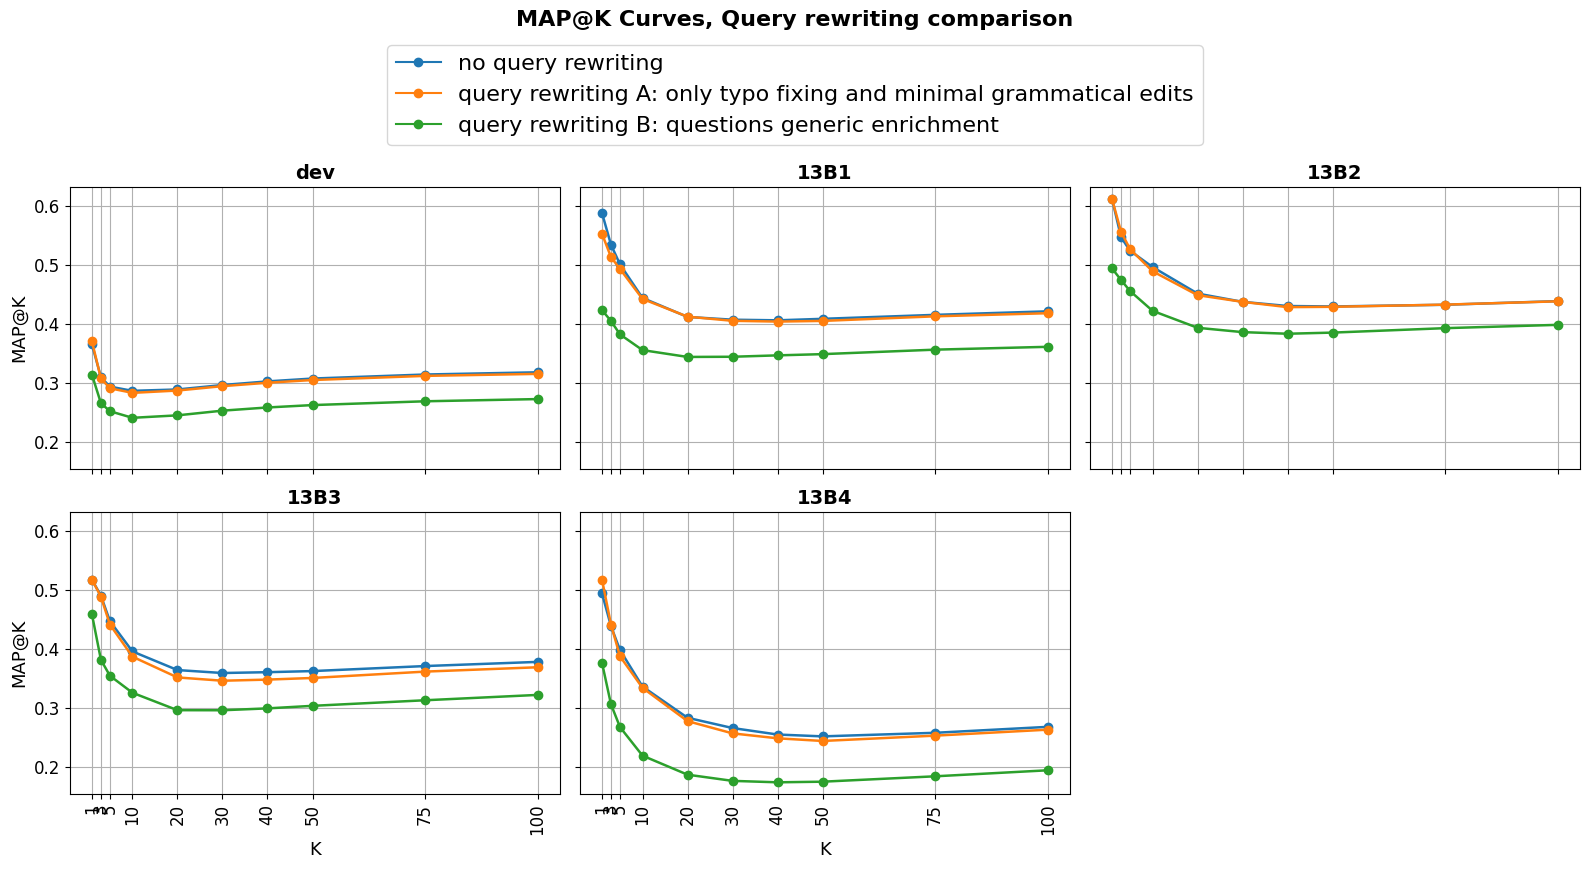

In [74]:
bge_local_dir = base_dir / "output" / "workflow_local_10pct_hpc_bge"

bge_local_run_dirs = {
    "CE Reranker (no rewriting)": bge_local_dir / "rerank" / "runs",
    "query rewriting A: only typo fixing and minimal grammatical edits": bge_local_dir / "rerank_body_rewrite_A" / "runs",
    "query rewriting B: questions generic enrichment": bge_local_dir / "rerank_body_rewrite_B" / "runs",
}

bge_local_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    for method_name, runs_dir in bge_local_run_dirs.items():
        candidates = list(runs_dir.glob(f"best_rrf_{split}_top*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        if split == train_split_id and train_overlap_qids:
            qid_col, _ = run_df.columns.tolist()
            run_df = run_df[~run_df[qid_col].astype(str).isin(train_overlap_qids)]
        map_vals = _map_at_ks_for_run(run_df, qrels_split, map_ks)
        bge_local_map_curves[method_name][split] = map_vals

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes_flat = list(axes.flat)

all_vals_bge = []
for method_dict in bge_local_map_curves.values():
    for split_vals in method_dict.values():
        all_vals_bge.extend(split_vals.values())
if all_vals_bge:
    y_min_bge = max(0.0, min(all_vals_bge) - 0.02)
    y_max_bge = min(1.0, max(all_vals_bge) + 0.02)
else:
    y_min_bge, y_max_bge = 0.0, 1.0

colors_bge_local = {
    "CE Reranker (no rewriting)": "#1f77b4",
    "query rewriting A: only typo fixing and minimal grammatical edits": "#ff7f0e",
    "query rewriting B: questions generic enrichment": "#2ca02c",
}

for idx, split in enumerate(splits_rerank):
    ax = axes_flat[idx]
    for method_name, method_dict in bge_local_map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            vals,
            marker="o",
            linewidth=1.8,
            color=colors_bge_local[method_name],
            label=method_name,
        )
    ax.set_title(split_labels.get(split, split), fontsize=14, fontweight="bold")
    ax.set_ylim(y_min_bge, y_max_bge)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(map_ks)
        ax.set_xticklabels([str(k) for k in map_ks], rotation=90)

for j in range(len(splits_rerank), len(axes_flat)):
    axes_flat[j].remove()

from matplotlib.lines import Line2D as _Line2D_bge
legend_bge_handles = [
    _Line2D_bge([0], [0], color=colors_bge_local[name], marker="o", linestyle="-", label=name)
    for name in colors_bge_local
]
fig.legend(
    handles=legend_bge_handles,
    labels=list(colors_bge_local),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    fontsize=16,
)
fig.suptitle(
    "MAP@K Curves, Query rewriting comparison",
    fontsize=16,
    fontweight="bold",
    y=1.08,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "10_bge_local_rerank_mapk.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/10b_bge_local_rerank_mapk_dev_vs_test_merged.png


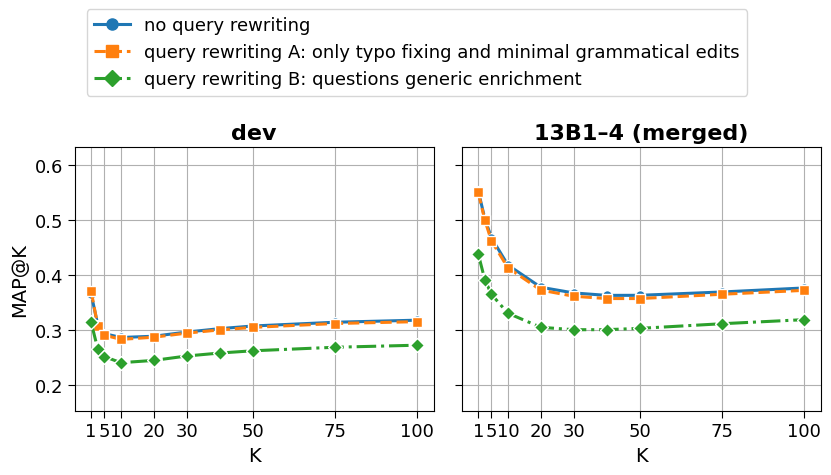

In [77]:
# Distinct linestyle + marker so overlapping curves (esp. blue vs orange) read clearly at each K.
_wn_mapk_x10b = _wn_mapk_xticks(map_ks)
_bge_10b_markers = {
    "CE Reranker (no rewriting)": "o",
    "query rewriting A: only typo fixing and minimal grammatical edits": "s",
    "query rewriting B: questions generic enrichment": "D",
}
_bge_10b_linestyles = {
    "CE Reranker (no rewriting)": "-",
    "query rewriting A: only typo fixing and minimal grammatical edits": "--",
    "query rewriting B: questions generic enrichment": "-.",
}
with plt.rc_context(WORKINGNOTE_FIG_RC):
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.2), sharex=True, sharey=True)

    for idx, (panel_label, panel_splits) in enumerate([
        ("dev", ["training14b_10pct_sample"]),
        ("13B1–4 (merged)", ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]),
    ]):
        ax = axes[idx]
        for method_name, method_dict in bge_local_map_curves.items():
            all_vals = []
            for s in panel_splits:
                if s in method_dict:
                    all_vals.append([method_dict[s].get(k, 0.0) for k in map_ks])
            if not all_vals:
                continue
            vals = np.mean(all_vals, axis=0)
            c = colors_bge_local[method_name]
            ax.plot(
                map_ks,
                vals,
                marker=_bge_10b_markers.get(method_name, "o"),
                linestyle=_bge_10b_linestyles.get(method_name, "-"),
                markersize=7,
                linewidth=2.2,
                color=c,
                label=method_name,
                markerfacecolor=c,
                markeredgecolor="white",
                markeredgewidth=1.0,
            )
        ax.set_title(panel_label, fontsize=16, fontweight="bold")
        ax.set_ylim(y_min_bge, y_max_bge)
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")
        if idx == 0:
            ax.set_ylabel("MAP@K")
        ax.set_xlabel("K")
        ax.set_xticks(_wn_mapk_x10b)
        ax.set_xticklabels([str(k) for k in _wn_mapk_x10b])

    legend_bge_handles_c = [
        _Line2D_bge(
            [0],
            [0],
            color=colors_bge_local[name],
            marker=_bge_10b_markers.get(name, "o"),
            linestyle=_bge_10b_linestyles.get(name, "-"),
            markersize=8,
            linewidth=2.2,
            label=name,
        )
        for name in colors_bge_local
    ]
    fig.legend(
        handles=legend_bge_handles_c,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        fontsize=13,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])

fig_path = output_dir / "10b_bge_local_rerank_mapk_dev_vs_test_merged.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 13. Low Recall@2000 Questions – Hybrid Retrieval
Table of questions where hybrid retrieval Recall@2000 < 0.33, sorted by recall ascending.
Helps diagnose the hardest queries for our retrieval pipeline.

In [60]:
import re


def _load_questions_full(path: Path):
    """Load question metadata: type, word count, body text."""
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    out = {}
    for q in data.get("questions", []):
        qid = q.get("id")
        if qid is None:
            continue
        qid = str(qid)
        body = (q.get("body") or "").strip()
        qtype = (q.get("type") or "unknown").lower()
        word_count = len(re.findall(r"\w+", body))
        out[qid] = {"type": qtype, "len_words": word_count, "question": body}
    return out


question_meta_by_split = {s: _load_questions_full(p) for s, p in qrels_paths.items()}

RECALL_K = 2000
RECALL_THRESHOLD = 0.33

hybrid_runs_dir = workflow_dir / "hybrid" / "runs"

low_recall_records = []
for split in splits:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    meta = question_meta_by_split.get(split, {})

    candidates = list(hybrid_runs_dir.glob(f"best_rrf_{split}_top*.tsv"))
    if not candidates:
        print(f"No hybrid run found for {split}")
        continue
    run_df = _load_run(candidates[0])
    qid_col, doc_col = run_df.columns.tolist()

    for qid, group in run_df.groupby(qid_col, sort=False):
        qid_str = str(qid)
        rels = qrels_split.get(qid_str)
        if not rels:
            continue
        docs = group[doc_col].tolist()
        recall = _recall_at_k(docs, set(rels), RECALL_K)
        if recall >= RECALL_THRESHOLD:
            continue
        info = meta.get(qid_str, {})
        low_recall_records.append({
            "split": split_labels.get(split, split),
            "qid": qid_str,
            "type": info.get("type", "unknown"),
            "len_words": info.get("len_words", np.nan),
            "n_rel": len(rels),
            f"Recall@{RECALL_K}": round(recall, 4),
            "question": info.get("question", ""),
        })

low_recall_df = pd.DataFrame(low_recall_records)
low_recall_df = low_recall_df.sort_values(f"Recall@{RECALL_K}").reset_index(drop=True)

print(f"Questions with Recall@{RECALL_K} < {RECALL_THRESHOLD}: {len(low_recall_df)}")
print(f"Splits represented: {low_recall_df['split'].value_counts().to_dict()}")
print()

display_cols = ["split", "qid", "type", "len_words", "n_rel", f"Recall@{RECALL_K}", "question"]
with pd.option_context("display.max_rows", None, "display.max_colwidth", 120, "display.width", 200):
    print(low_recall_df[display_cols].to_string(index=False))

Questions with Recall@2000 < 0.33: 46
Splits represented: {'dev': 43, '13B3': 2, '13B4': 1}

split                      qid    type  len_words  n_rel  Recall@2000                                                                                             question
  dev 5e482160d14c9f295d00000c    list          6      3       0.0000                                                      List five proteins with antioxidant properties?
  dev 5c89773ed558e5f23200000a factoid         10      1       0.0000                                  Which gene therapy treatment is FDA approved for retinal dystrophy?
  dev 5c9f79c3ecadf2e73f00003d    list         16      1       0.0000 What are the 3 types of immunoglobulin heavy chain containing antibodies found in human breast milk?
  dev 660c0a85fdcbea915f000030    list          8      1       0.0000                                             What are common complications of prematurity for babies?
  dev 5e80669e835f4e4777000025 summary          5   

## 14. MAP@K Curves by Question Length – Rerank Only
First, inspect the overall question length distribution (dev + test merged),
and compute length cutoffs for top/mid/bottom 33%. Then plot MAP@K curves
by coarse length bins (short, mid, long).

Total questions with length info (dev + test): 923
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/12a_all_question_length_hist.png


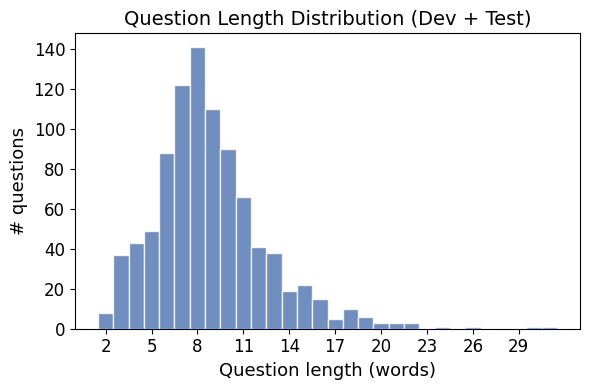

Approx. tertile cutoffs (dev + test):
  bottom 33% ≤ 7 words
  middle 33% between 8 and 10 words
  top 33% ≥ 11 words
Per-query AP@K rows (length-stratified, rerank only): 9230
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/12_rerank_mapk_by_length_bins.png


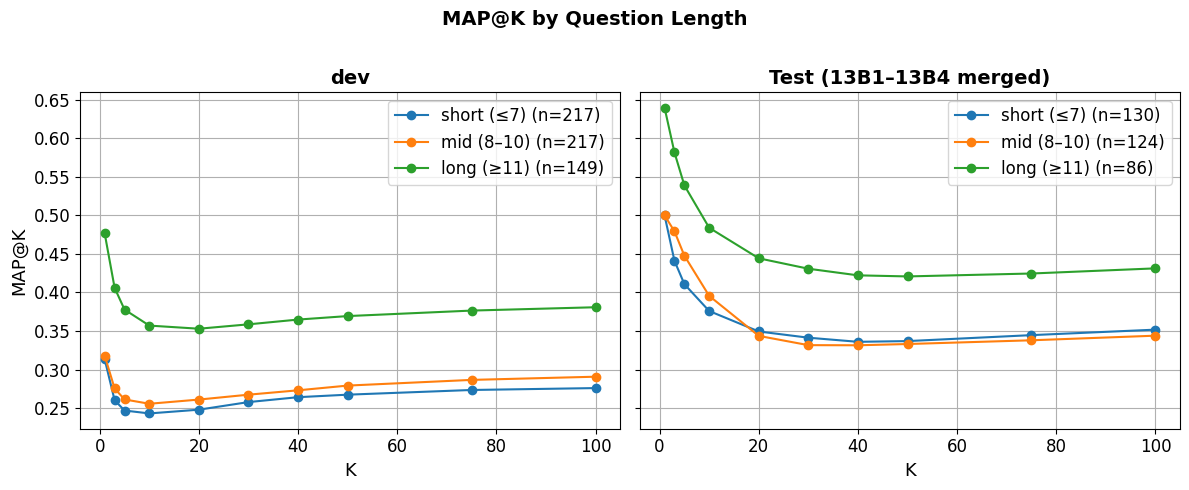

In [87]:
# All-question length distribution (dev + test)
all_lengths = []
for split, meta in question_meta_by_split.items():
    for info in meta.values():
        lw = info.get("len_words")
        if lw is None or (isinstance(lw, float) and np.isnan(lw)):
            continue
        all_lengths.append(int(lw))

all_lengths = np.array(all_lengths, dtype=int)
print("Total questions with length info (dev + test):", len(all_lengths))

if len(all_lengths) > 0:
    # Histogram
    bins = np.arange(all_lengths.min() - 0.5, all_lengths.max() + 1.5, 1)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(all_lengths, bins=bins, color="#4c72b0", alpha=0.8, edgecolor="white")
    ax.set_xlabel("Question length (words)")
    ax.set_ylabel("# questions")
    ax.set_title("Question Length Distribution (Dev + Test)")
    step = max(1, int(np.ceil((all_lengths.max() - all_lengths.min()) / 10)))
    ax.set_xticks(np.arange(all_lengths.min(), all_lengths.max() + 1, step))
    plt.tight_layout()
    fig_path = output_dir / "12a_all_question_length_hist.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

    # 33% / 66% percentiles
    p33 = int(np.percentile(all_lengths, 33))
    p66 = int(np.percentile(all_lengths, 66))
    print(f"Approx. tertile cutoffs (dev + test):")
    print(f"  bottom 33% ≤ {p33} words")
    print(f"  middle 33% between {p33+1} and {p66} words")
    print(f"  top 33% ≥ {p66+1} words")
else:
    print("No question length values available.")

# Rerank-only MAP@K by fixed bins (short/mid/long)
rerank_runs_dir = workflow_dir / "rerank" / "runs"

map_ks_len = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]


def _len_bin_3way(n: float | int | None) -> str | None:
    """Bin question length using empirical tertiles: ≤7, 8–10, ≥11 words."""
    if n is None or (isinstance(n, float) and np.isnan(n)):
        return None
    n_int = int(n)
    if n_int <= 7:
        return "short (≤7)"
    if n_int <= 10:
        return "mid (8–10)"
    return "long (≥11)"


len_records: list[dict[str, object]] = []

for split in [dev_split] + test_splits:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue

    meta_split = question_meta_by_split.get(split, {})
    candidates = list(rerank_runs_dir.glob(f"best_rrf_{split}_top*.tsv"))
    if not candidates:
        print(f"No rerank run found for {split}")
        continue

    run_df = _load_run(candidates[0])
    qid_col, doc_col = run_df.columns.tolist()

    for qid, group in run_df.groupby(qid_col, sort=False):
        qid_str = str(qid)
        rels = qrels_split.get(qid_str)
        if not rels:
            continue

        meta = meta_split.get(qid_str, {})
        q_len = meta.get("len_words")
        bin_label = _len_bin_3way(q_len)
        if bin_label is None:
            continue

        docs = group[doc_col].tolist()
        for k in map_ks_len:
            ap = _ap_at_k(docs, set(rels), k)
            len_records.append(
                {
                    "split": split,
                    "qid": qid_str,
                    "len_bin": bin_label,
                    "k": k,
                    "AP@K": ap,
                }
            )

len_df = pd.DataFrame(len_records)
print("Per-query AP@K rows (length-stratified, rerank only):", len(len_df))

if not len_df.empty:
    # Dev/train panel (single split)
    dev_df = len_df[len_df["split"] == dev_split].copy()
    # Test panel (all four test splits merged)
    test_df = len_df[len_df["split"].isin(test_splits)].copy()

    # Per-bin query counts (unique qids)
    dev_counts = (
        dev_df[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )
    test_counts = (
        test_df[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )

    dev_summary = (
        dev_df.groupby(["len_bin", "k"], as_index=False)["AP@K"]
        .mean()
        .rename(columns={"AP@K": "MAP@K"})
    )
    test_summary = (
        test_df.groupby(["len_bin", "k"], as_index=False)["AP@K"]
        .mean()
        .rename(columns={"AP@K": "MAP@K"})
    )

    len_bin_order = ["short (≤7)", "mid (8–10)", "long (≥11)"]
    colors_len = {
        "short (≤7)": "#1f77b4",
        "mid (8–10)": "#ff7f0e",
        "long (≥11)": "#2ca02c",
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    # Dev/train panel
    ax = axes[0]
    for bin_label in len_bin_order:
        sub = dev_summary[dev_summary["len_bin"] == bin_label].sort_values("k")
        if sub.empty:
            continue
        n_q = dev_counts.get(bin_label, 0)
        ax.plot(
            sub["k"],
            sub["MAP@K"],
            marker="o",
            color=colors_len[bin_label],
            label=f"{bin_label} (n={n_q})",
        )
    ax.set_title("dev", fontweight="bold")
    ax.set_xlabel("K")
    ax.set_ylabel("MAP@K")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    ax.legend(
        loc="upper right",
        fontsize=12,
        title="",
    )

    # Test panel (all four test splits merged)
    ax = axes[1]
    for bin_label in len_bin_order:
        sub = test_summary[test_summary["len_bin"] == bin_label].sort_values("k")
        if sub.empty:
            continue
        n_q = test_counts.get(bin_label, 0)
        ax.plot(
            sub["k"],
            sub["MAP@K"],
            marker="o",
            color=colors_len[bin_label],
            label=f"{bin_label} (n={n_q})",
        )
    ax.set_title("Test (13B1–13B4 merged)", fontweight="bold")
    ax.set_xlabel("K")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    ax.legend(
        loc="upper right",
        fontsize=12,
        title="",
    )

    fig.suptitle(
        "MAP@K by Question Length",
        fontsize=14,
        fontweight="bold",
        y=0.97,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig_path = output_dir / "12_rerank_mapk_by_length_bins.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("No per-query rerank metrics available for length-stratified MAP@K.")

## 15. MAP@K Curves by Question Length – Rerank vs Hybrid
Compare rerank vs hybrid runs, stratified by question length bins:
short (≤6 words), mid (7–14 words), long (≥15 words).
Two panels: dev/train split vs all four test splits merged.
Rerank uses solid lines; hybrid uses dashed lines with the same colors (per length bin).

Per-query AP@K rows (length-stratified, rerank vs hybrid): 18460
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/13_rerank_vs_hybrid_mapk_by_length_bins.png


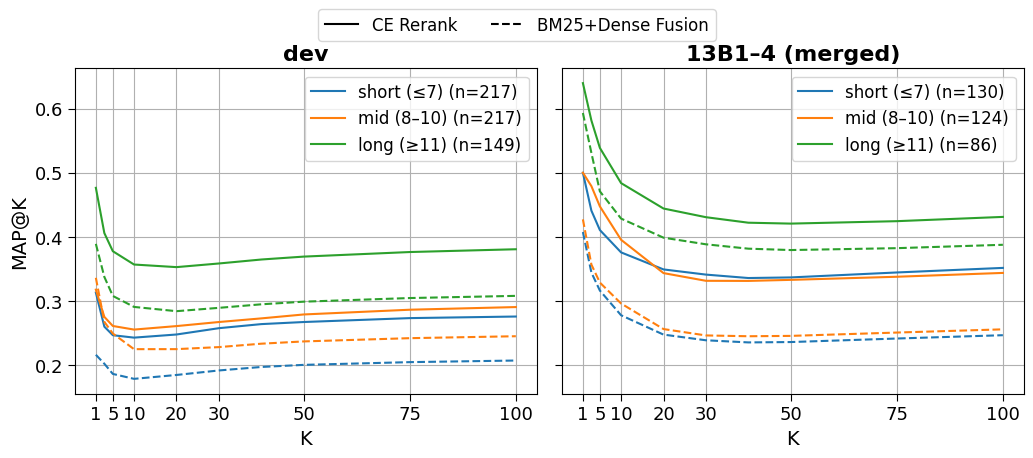

In [88]:
hybrid_runs_dir = workflow_dir / "hybrid" / "runs"

map_ks_len_compare = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]

len_compare_records: list[dict[str, object]] = []

for split in [dev_split] + test_splits:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue

    meta_split = question_meta_by_split.get(split, {})

    for method_name, runs_dir in [("Rerank", rerank_runs_dir), ("Hybrid", hybrid_runs_dir)]:
        candidates = list(runs_dir.glob(f"best_rrf_{split}_top*.tsv"))
        if not candidates:
            print(f"No {method_name.lower()} run found for {split}")
            continue

        run_df = _load_run(candidates[0])
        qid_col, doc_col = run_df.columns.tolist()

        for qid, group in run_df.groupby(qid_col, sort=False):
            qid_str = str(qid)
            rels = qrels_split.get(qid_str)
            if not rels:
                continue

            meta = meta_split.get(qid_str, {})
            q_len = meta.get("len_words")
            bin_label = _len_bin_3way(q_len)
            if bin_label is None:
                continue

            docs = group[doc_col].tolist()
            for k in map_ks_len_compare:
                ap = _ap_at_k(docs, set(rels), k)
                len_compare_records.append(
                    {
                        "split": split,
                        "method": method_name,
                        "qid": qid_str,
                        "len_bin": bin_label,
                        "k": k,
                        "AP@K": ap,
                    }
                )

len_compare_df = pd.DataFrame(len_compare_records)
print("Per-query AP@K rows (length-stratified, rerank vs hybrid):", len(len_compare_df))

if not len_compare_df.empty:
    dev_df_cmp = len_compare_df[len_compare_df["split"] == dev_split].copy()
    test_df_cmp = len_compare_df[len_compare_df["split"].isin(test_splits)].copy()

    dev_counts_cmp = (
        dev_df_cmp[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )
    test_counts_cmp = (
        test_df_cmp[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )

    dev_summary_cmp = (
        dev_df_cmp.groupby(["method", "len_bin", "k"], as_index=False)["AP@K"]
        .mean()
        .rename(columns={"AP@K": "MAP@K"})
    )
    test_summary_cmp = (
        test_df_cmp.groupby(["method", "len_bin", "k"], as_index=False)["AP@K"]
        .mean()
        .rename(columns={"AP@K": "MAP@K"})
    )

    len_bin_order_cmp = ["short (≤7)", "mid (8–10)", "long (≥11)"]
    colors_len_cmp = {
        "short (≤7)": "#1f77b4",
        "mid (8–10)": "#ff7f0e",
        "long (≥11)": "#2ca02c",
    }

    _wn_x13 = _wn_mapk_xticks(map_ks_len_compare)
    with plt.rc_context(WORKINGNOTE_FIG_RC):
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 5), sharex=True, sharey=True)

        # Dev/train panel
        ax = axes[0]
        for bin_label in len_bin_order_cmp:
            for method_name, linestyle in [("Rerank", "-"), ("Hybrid", "--")]:
                sub = dev_summary_cmp[
                    (dev_summary_cmp["len_bin"] == bin_label)
                    & (dev_summary_cmp["method"] == method_name)
                ].sort_values("k")
                if sub.empty:
                    continue
                ax.plot(
                    sub["k"],
                    sub["MAP@K"],
                    linestyle=linestyle,
                    color=colors_len_cmp[bin_label],
                )
        ax.set_title("dev", fontweight="bold")
        ax.set_xlabel("K")
        ax.set_ylabel("MAP@K")
        ax.set_xticks(_wn_x13)
        ax.set_xticklabels([str(k) for k in _wn_x13])
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")

        # Color legend for dev (length bins with n)
        from matplotlib.lines import Line2D as _Line2D_len

        dev_color_handles = [
            _Line2D_len(
                [], [],
                color=colors_len_cmp[bin_label],
                linestyle="-",
                label=f"{bin_label} (n={dev_counts_cmp.get(bin_label, 0)})",
            )
            for bin_label in len_bin_order_cmp
            if dev_counts_cmp.get(bin_label, 0) > 0
        ]
        if dev_color_handles:
            ax.legend(
                handles=dev_color_handles,
                loc="upper right",
                fontsize=12,
            )

        # Test panel (all four test splits merged)
        ax = axes[1]
        for bin_label in len_bin_order_cmp:
            for method_name, linestyle in [("Rerank", "-"), ("Hybrid", "--")]:
                sub = test_summary_cmp[
                    (test_summary_cmp["len_bin"] == bin_label)
                    & (test_summary_cmp["method"] == method_name)
                ].sort_values("k")
                if sub.empty:
                    continue
                ax.plot(
                    sub["k"],
                    sub["MAP@K"],
                    linestyle=linestyle,
                    color=colors_len_cmp[bin_label],
                )
        ax.set_title("13B1–4 (merged)", fontweight="bold")
        ax.set_xlabel("K")
        ax.set_xticks(_wn_x13)
        ax.set_xticklabels([str(k) for k in _wn_x13])
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")

        # Color legend for test (length bins with n)
        test_color_handles = [
            _Line2D_len(
                [], [],
                color=colors_len_cmp[bin_label],
                linestyle="-",
                label=f"{bin_label} (n={test_counts_cmp.get(bin_label, 0)})",
            )
            for bin_label in len_bin_order_cmp
            if test_counts_cmp.get(bin_label, 0) > 0
        ]
        if test_color_handles:
            ax.legend(
                handles=test_color_handles,
                loc="upper right",
                fontsize=12,
            )

        # Global legend for line styles (methods) – same n, so no counts here
        style_handles = [
            _Line2D_len([], [], color="black", linestyle="-", label="CE Rerank"),
            _Line2D_len([], [], color="black", linestyle="--", label="BM25+Dense Fusion"),
        ]
        fig.legend(
            handles=style_handles,
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(0.5, 0.93),
            fontsize=12,
            title="",
        )

        plt.tight_layout(rect=[0, 0, 1, 0.88])

    fig_path = output_dir / "13_rerank_vs_hybrid_mapk_by_length_bins.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("No per-query metrics available for length-stratified rerank vs hybrid MAP@K.")

In [89]:

#

## 16. Rerank MAP@K and Recall@K Curves by Question Length
Rerank-only curves using `output/workflow_baseline_full_run_both_routes/rerank`
runs, recomputing both MAP@K and Recall@K directly from the run files.
MAP@K uses K ∈ {10, 20, 30, 40, 50, 75, 100, 150, 200}; Recall@K is computed
on the same K values so both curves are defined smoothly on [10, 200].
Two panels: dev/train vs all four test splits merged; solid = MAP@K,
dashed = Recall@K; colors = length bins (short ≤7, mid 8–10, long ≥11).

Per-query MAP@K/Recall@K rows (rerank, length-stratified): 10153
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/14_rerank_mapk_recall_by_length_bins.png


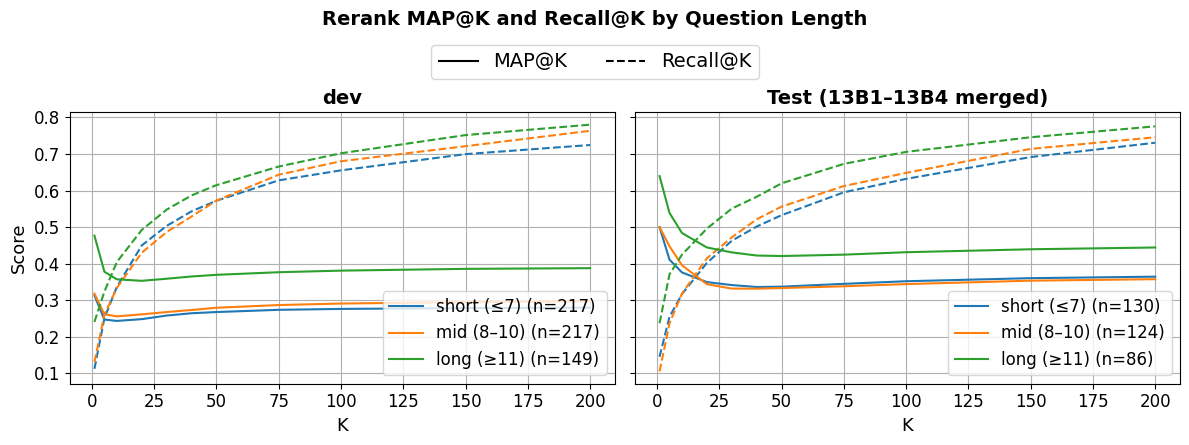

In [90]:
ks_rerank_len = [1, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200]

rerank_len_records: list[dict[str, object]] = []

for split in [dev_split] + test_splits:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue

    meta_split = question_meta_by_split.get(split, {})
    candidates = list(rerank_runs_dir.glob(f"best_rrf_{split}_top*.tsv"))
    if not candidates:
        print(f"No rerank run found for {split} (MAP/Recall-by-length).")
        continue

    run_df = _load_run(candidates[0])
    qid_col, doc_col = run_df.columns.tolist()

    for qid, group in run_df.groupby(qid_col, sort=False):
        qid_str = str(qid)
        rels = qrels_split.get(qid_str)
        if not rels:
            continue

        meta = meta_split.get(qid_str, {})
        q_len = meta.get("len_words")
        bin_label = _len_bin_3way(q_len)
        if bin_label is None:
            continue

        docs = group[doc_col].tolist()
        for k in ks_rerank_len:
            rerank_len_records.append(
                {
                    "split": split,
                    "qid": qid_str,
                    "len_bin": bin_label,
                    "k": k,
                    "MAP@K": _ap_at_k(docs, set(rels), k),
                    "Recall@K": _recall_at_k(docs, set(rels), k),
                }
            )

rerank_len_df = pd.DataFrame(rerank_len_records)
print("Per-query MAP@K/Recall@K rows (rerank, length-stratified):", len(rerank_len_df))

if not rerank_len_df.empty:
    dev_df_r = rerank_len_df[rerank_len_df["split"] == dev_split].copy()
    test_df_r = rerank_len_df[rerank_len_df["split"].isin(test_splits)].copy()

    # Per-bin query counts (for legends)
    dev_counts_r = (
        dev_df_r[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )
    test_counts_r = (
        test_df_r[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )

    dev_summary_r = (
        dev_df_r.groupby(["len_bin", "k"], as_index=False)[["MAP@K", "Recall@K"]]
        .mean()
    )
    test_summary_r = (
        test_df_r.groupby(["len_bin", "k"], as_index=False)[["MAP@K", "Recall@K"]]
        .mean()
    )

    len_bin_order_r = ["short (≤7)", "mid (8–10)", "long (≥11)"]
    colors_len_r = {
        "short (≤7)": "#1f77b4",
        "mid (8–10)": "#ff7f0e",
        "long (≥11)": "#2ca02c",
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    # Dev/train panel
    ax = axes[0]
    for bin_label in len_bin_order_r:
        sub = dev_summary_r[dev_summary_r["len_bin"] == bin_label].sort_values("k")
        if sub.empty:
            continue
        ax.plot(
            sub["k"],
            sub["MAP@K"],
            linestyle="-",
            color=colors_len_r[bin_label],
        )
        ax.plot(
            sub["k"],
            sub["Recall@K"],
            linestyle="--",
            color=colors_len_r[bin_label],
        )
    ax.set_title("dev", fontweight="bold")
    ax.set_xlabel("K")
    ax.set_ylabel("Score")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

    from matplotlib.lines import Line2D as _Line2D_rerank_len

    dev_color_handles_r = [
        _Line2D_rerank_len(
            [], [],
            color=colors_len_r[bin_label],
            linestyle="-",
            label=f"{bin_label} (n={dev_counts_r.get(bin_label, 0)})",
        )
        for bin_label in len_bin_order_r
        if dev_counts_r.get(bin_label, 0) > 0
    ]
    if dev_color_handles_r:
        ax.legend(
            handles=dev_color_handles_r,
            loc="lower right",
            fontsize=12,
            title="",
        )

    # Test panel
    ax = axes[1]
    for bin_label in len_bin_order_r:
        sub = test_summary_r[test_summary_r["len_bin"] == bin_label].sort_values("k")
        if sub.empty:
            continue
        ax.plot(
            sub["k"],
            sub["MAP@K"],
            linestyle="-",
            color=colors_len_r[bin_label],
        )
        ax.plot(
            sub["k"],
            sub["Recall@K"],
            linestyle="--",
            color=colors_len_r[bin_label],
        )
    ax.set_title("Test (13B1–13B4 merged)", fontweight="bold")
    ax.set_xlabel("K")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

    test_color_handles_r = [
        _Line2D_rerank_len(
            [], [],
            color=colors_len_r[bin_label],
            linestyle="-",
            label=f"{bin_label} (n={test_counts_r.get(bin_label, 0)})",
        )
        for bin_label in len_bin_order_r
        if test_counts_r.get(bin_label, 0) > 0
    ]
    if test_color_handles_r:
        ax.legend(
            handles=test_color_handles_r,
            loc="lower right",
            fontsize=12,
            title="",
        )

    # Global legend for style (MAP vs Recall)
    style_handles_r = [
        _Line2D_rerank_len([], [], color="black", linestyle="-", label="MAP@K"),
        _Line2D_rerank_len([], [], color="black", linestyle="--", label="Recall@K"),
    ]
    fig.legend(
        handles=style_handles_r,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.83),
        fontsize=14,
        title="",
    )

    fig.suptitle(
        "Rerank MAP@K and Recall@K by Question Length",
        fontsize=14,
        fontweight="bold",
        y=0.88,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.82])
    fig_path = output_dir / "14_rerank_mapk_recall_by_length_bins.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("No per-query rerank metrics available for combined MAP@K/Recall@K curves.")

## 17. Hybrid Recall@K Curves by Question Length
Stage-1 hybrid retrieval only, Recall@K curves stratified by question length:
short (≤7 words), mid (8–10 words), long (≥11 words).
Two panels: dev/train split vs all four test splits merged.

Per-query Recall@K rows (hybrid, length-stratified): 8307
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/14_hybrid_recall_by_length_bins.png


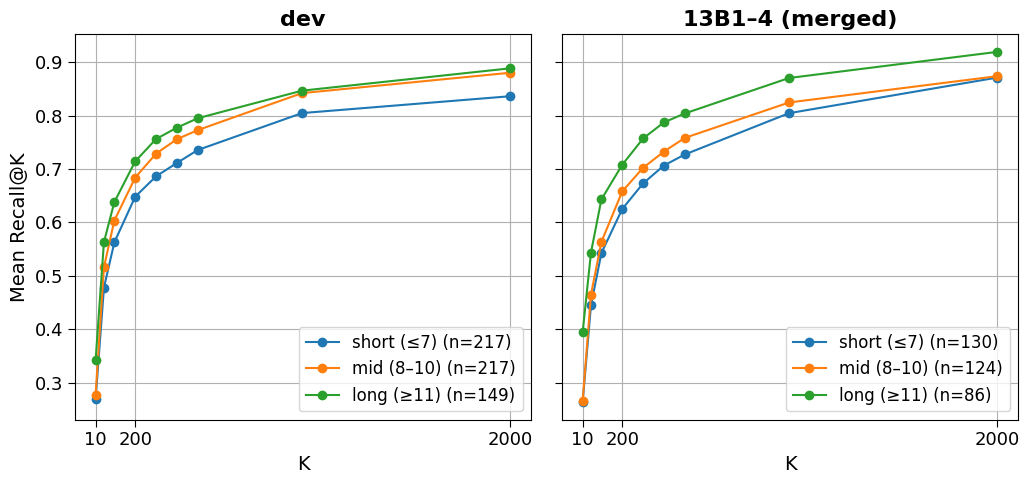

In [91]:
recall_ks_len = [10, 50, 100, 200, 300, 400, 500, 1000, 2000]

hybrid_recall_len_records: list[dict[str, object]] = []

for split in [dev_split] + test_splits:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue

    meta_split = question_meta_by_split.get(split, {})
    candidates = list(hybrid_runs_dir.glob(f"best_rrf_{split}_top*.tsv"))
    if not candidates:
        print(f"No hybrid run found for {split} (recall-by-length).")
        continue

    run_df = _load_run(candidates[0])
    qid_col, doc_col = run_df.columns.tolist()

    for qid, group in run_df.groupby(qid_col, sort=False):
        qid_str = str(qid)
        rels = qrels_split.get(qid_str)
        if not rels:
            continue

        meta = meta_split.get(qid_str, {})
        q_len = meta.get("len_words")
        bin_label = _len_bin_3way(q_len)
        if bin_label is None:
            continue

        docs = group[doc_col].tolist()
        for k in recall_ks_len:
            hybrid_recall_len_records.append(
                {
                    "split": split,
                    "qid": qid_str,
                    "len_bin": bin_label,
                    "k": k,
                    "Recall@K": _recall_at_k(docs, set(rels), k),
                }
            )

hybrid_recall_len_df = pd.DataFrame(hybrid_recall_len_records)
print("Per-query Recall@K rows (hybrid, length-stratified):", len(hybrid_recall_len_df))

if not hybrid_recall_len_df.empty:
    dev_rec_df = hybrid_recall_len_df[hybrid_recall_len_df["split"] == dev_split].copy()
    test_rec_df = hybrid_recall_len_df[hybrid_recall_len_df["split"].isin(test_splits)].copy()

    dev_counts_rec = (
        dev_rec_df[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )
    test_counts_rec = (
        test_rec_df[["len_bin", "qid"]]
        .drop_duplicates()
        .groupby("len_bin")["qid"]
        .nunique()
        .to_dict()
    )

    dev_rec_summary = (
        dev_rec_df.groupby(["len_bin", "k"], as_index=False)["Recall@K"]
        .mean()
        .rename(columns={"Recall@K": "MeanRecall@K"})
    )
    test_rec_summary = (
        test_rec_df.groupby(["len_bin", "k"], as_index=False)["Recall@K"]
        .mean()
        .rename(columns={"Recall@K": "MeanRecall@K"})
    )

    len_bin_order_rec = ["short (≤7)", "mid (8–10)", "long (≥11)"]
    colors_len_rec = {
        "short (≤7)": "#1f77b4",
        "mid (8–10)": "#ff7f0e",
        "long (≥11)": "#2ca02c",
    }

    _wn_x14 = _wn_hybrid_recall_xticks(recall_ks_len)
    with plt.rc_context(WORKINGNOTE_FIG_RC):
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 5), sharex=True, sharey=True)

        # Dev/train panel
        ax = axes[0]
        for bin_label in len_bin_order_rec:
            sub = dev_rec_summary[dev_rec_summary["len_bin"] == bin_label].sort_values("k")
            if sub.empty:
                continue
            n_q = dev_counts_rec.get(bin_label, 0)
            ax.plot(
                sub["k"],
                sub["MeanRecall@K"],
                marker="o",
                markersize=6,
                color=colors_len_rec[bin_label],
                label=f"{bin_label} (n={n_q})",
            )
        ax.set_title("dev", fontweight="bold")
        ax.set_xlabel("K")
        ax.set_ylabel("Mean Recall@K")
        ax.set_xticks(_wn_x14)
        ax.set_xticklabels([str(k) for k in _wn_x14])
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")
        ax.legend(loc="lower right", fontsize=12, title="")

        # Test panel (all four test splits merged)
        ax = axes[1]
        for bin_label in len_bin_order_rec:
            sub = test_rec_summary[test_rec_summary["len_bin"] == bin_label].sort_values("k")
            if sub.empty:
                continue
            n_q = test_counts_rec.get(bin_label, 0)
            ax.plot(
                sub["k"],
                sub["MeanRecall@K"],
                marker="o",
                markersize=6,
                color=colors_len_rec[bin_label],
                label=f"{bin_label} (n={n_q})",
            )
        ax.set_title("13B1–4 (merged)", fontweight="bold")
        ax.set_xlabel("K")
        ax.set_xticks(_wn_x14)
        ax.set_xticklabels([str(k) for k in _wn_x14])
        ax.grid(True, axis="y")
        ax.grid(True, axis="x")
        ax.legend(loc="lower right", fontsize=12, title="")

        plt.tight_layout()

    fig_path = output_dir / "14_hybrid_recall_by_length_bins.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("No per-query hybrid Recall@K metrics available for length-stratified curves.")

## 17b. Working-note figure: MAP@K (top) + Hybrid Recall@K (bottom) by question length
Combines §15 (rerank vs hybrid MAP@K) and §17 (hybrid Recall@K) into a single
2×2 figure. Top row: rerank (solid) vs hybrid (dashed). Bottom row: hybrid
Recall plotted dashed to match the hybrid linestyle convention from the top.

Saved (direct to working-note dir): /Users/yun/develop/BioASQ/workingnotes/figures/08_length_mapk_and_recall.png


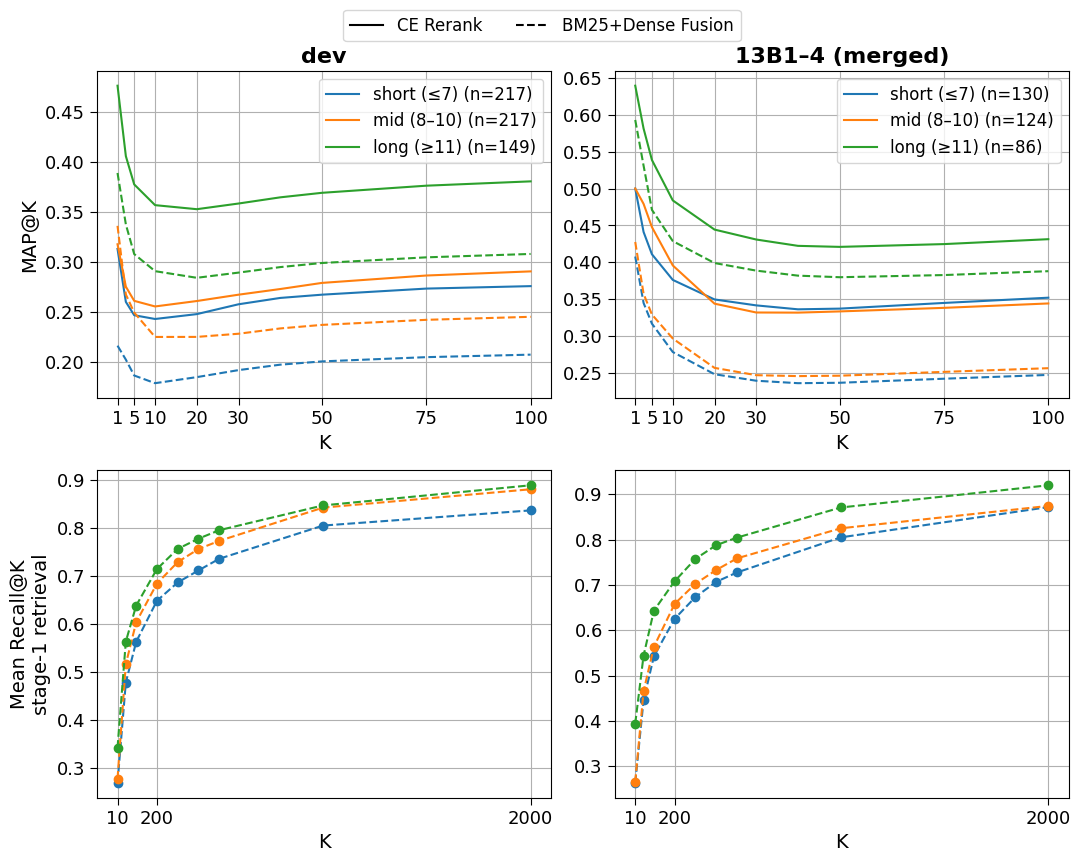

In [94]:
if not len_compare_df.empty and not hybrid_recall_len_df.empty:
    from matplotlib.lines import Line2D as _Line2D_combined

    len_bin_order_combined = ["short (≤7)", "mid (8–10)", "long (≥11)"]
    colors_len_combined = {
        "short (≤7)": "#1f77b4",
        "mid (8–10)": "#ff7f0e",
        "long (≥11)": "#2ca02c",
    }

    _wn_x_top = _wn_mapk_xticks(map_ks_len_compare)
    _wn_x_bot = _wn_hybrid_recall_xticks(recall_ks_len)

    with plt.rc_context(WORKINGNOTE_FIG_RC):
        fig, axes = plt.subplots(2, 2, figsize=(11, 9))

        # Top row: MAP@K (rerank solid, hybrid dashed)
        top_panels = [
            ("dev", dev_summary_cmp, dev_counts_cmp),
            ("13B1–4 (merged)", test_summary_cmp, test_counts_cmp),
        ]
        for col_idx, (panel_title, summary_df, counts_dict) in enumerate(top_panels):
            ax = axes[0, col_idx]
            for bin_label in len_bin_order_combined:
                for method_name, linestyle in [("Rerank", "-"), ("Hybrid", "--")]:
                    sub = summary_df[
                        (summary_df["len_bin"] == bin_label)
                        & (summary_df["method"] == method_name)
                    ].sort_values("k")
                    if sub.empty:
                        continue
                    ax.plot(
                        sub["k"],
                        sub["MAP@K"],
                        linestyle=linestyle,
                        color=colors_len_combined[bin_label],
                    )
            ax.set_title(panel_title, fontweight="bold")
            ax.set_xlabel("K")
            if col_idx == 0:
                ax.set_ylabel("MAP@K")
            ax.set_xticks(_wn_x_top)
            ax.set_xticklabels([str(k) for k in _wn_x_top])
            ax.grid(True, axis="y")
            ax.grid(True, axis="x")
            color_handles = [
                _Line2D_combined(
                    [], [],
                    color=colors_len_combined[bin_label],
                    linestyle="-",
                    label=f"{bin_label} (n={counts_dict.get(bin_label, 0)})",
                )
                for bin_label in len_bin_order_combined
                if counts_dict.get(bin_label, 0) > 0
            ]
            if color_handles:
                ax.legend(handles=color_handles, loc="upper right", fontsize=12)

        # Bottom row: Hybrid Recall@K (dashed for consistency with top-row hybrid)
        bot_panels = [
            ("dev", dev_rec_summary),
            ("13B1–4 (merged)", test_rec_summary),
        ]
        for col_idx, (_panel_title, summary_df) in enumerate(bot_panels):
            ax = axes[1, col_idx]
            for bin_label in len_bin_order_combined:
                sub = summary_df[summary_df["len_bin"] == bin_label].sort_values("k")
                if sub.empty:
                    continue
                ax.plot(
                    sub["k"],
                    sub["MeanRecall@K"],
                    linestyle="--",
                    marker="o",
                    markersize=6,
                    color=colors_len_combined[bin_label],
                )
            ax.set_xlabel("K")
            if col_idx == 0:
                ax.set_ylabel("Mean Recall@K\nstage-1 retrieval")
            ax.set_xticks(_wn_x_bot)
            ax.set_xticklabels([str(k) for k in _wn_x_bot])
            ax.grid(True, axis="y")
            ax.grid(True, axis="x")

        # Global linestyle legend (rerank vs hybrid), placed above the top row
        style_handles = [
            _Line2D_combined([], [], color="black", linestyle="-", label="CE Rerank"),
            _Line2D_combined([], [], color="black", linestyle="--", label="BM25+Dense Fusion"),
        ]
        fig.legend(
            handles=style_handles,
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(0.5, 0.965),
            fontsize=12,
        )

        plt.tight_layout(rect=[0, 0, 1, 0.935])

    fig_path_wn = wn_output_dir / "08_length_mapk_and_recall.png"
    plt.savefig(fig_path_wn, dpi=150, bbox_inches="tight")
    print("Saved (direct to working-note dir):", fig_path_wn)
    plt.show()
else:
    print("Skipping combined length figure — upstream dataframes are empty.")

## 18. Copy selected figures into `workingnotes/figures/`
This is the canonical list of figures used in the working note. Anything not
listed here stays in the notebook's debug `figures/` directory but is not
copied to the working-note folder. The three merged figures
(`07_mapk_recall_by_gold_bucket.png`, `08_length_mapk_and_recall.png`,
`09_snippet_ablation.png`) are written directly to `wn_output_dir` by their
own sections above and are not copied here.

In [99]:
import shutil

workingnote_copy_map: dict[Path, str] = {
    output_dir / "01b_stage1_recall_dev_vs_test_merged.png":           "02_stage1_recall.png",
    output_dir / "02b_hybrid_rerank_fusion_recall_dev_vs_test_merged.png": "03_rerank_recall.png",
    output_dir / "04b_hybrid_rerank_fusion_mapk_dev_vs_test_merged.png":   "04_rerank_mapk.png",
    output_dir / "07b_rerankers_mapk_dev_vs_test_merged.png":             "05_reranker_comparison.png",
    output_dir / "05_gold_count_hist_all.png":                            "06_gold_count_hist.png",
    output_dir / "10b_bge_local_rerank_mapk_dev_vs_test_merged.png":      "11_query_rewriting.png",
    # HyDE figure is produced by `dense_hyde_fusion_sweep.py`, not this notebook.
    base_dir / "output" / "retrieval_test" / "dense_hyde_fusion_sweep"
        / "dense_hyde_vs_orig_recall_curves.png":                          "10_hyde_dense_recall.png",
}

missing: list[Path] = []
for src, dst_name in workingnote_copy_map.items():
    dst = wn_output_dir / dst_name
    if src.exists():
        shutil.copyfile(src, dst)
        print(f"copied  {src.name}  →  workingnotes/figures/{dst_name}")
    else:
        missing.append(src)
        print(f"MISSING {src}")

if missing:
    print(f"\n{len(missing)} source figure(s) missing — rerun their notebooks first.")
else:
    print("\nAll working-note figures populated.")
print("Final working-note figures in:", wn_output_dir)

copied  01b_stage1_recall_dev_vs_test_merged.png  →  workingnotes/figures/02_stage1_recall.png
copied  02b_hybrid_rerank_fusion_recall_dev_vs_test_merged.png  →  workingnotes/figures/03_rerank_recall.png
copied  04b_hybrid_rerank_fusion_mapk_dev_vs_test_merged.png  →  workingnotes/figures/04_rerank_mapk.png
copied  07b_rerankers_mapk_dev_vs_test_merged.png  →  workingnotes/figures/05_reranker_comparison.png
copied  05_gold_count_hist_all.png  →  workingnotes/figures/06_gold_count_hist.png
copied  10b_bge_local_rerank_mapk_dev_vs_test_merged.png  →  workingnotes/figures/11_query_rewriting.png
copied  dense_hyde_vs_orig_recall_curves.png  →  workingnotes/figures/10_hyde_dense_recall.png

All working-note figures populated.
Final working-note figures in: /Users/yun/develop/BioASQ/workingnotes/figures
